# L07: Trees - Random Forests & Gradient Boosting

In L5 and L6, we built neural networks for tabular data - first understanding the mechanics, then building a full pipeline with embeddings, preprocessing, and evaluation. The MLP worked. But here's the honest truth: for tabular data, tree-based models often win. They're faster to train, easier to interpret, need less preprocessing, and frequently deliver equal or better accuracy.

This notebook introduces a completely different family of algorithms. All of these algorithms work for both regression (predicting a number) and classification (predicting a category) - the core logic is the same, only the scoring function changes. This notebook focuses on regression (predicting bulldozer prices), but everything you learn applies directly to classification too.

We start with **decision trees** - the simplest tree model and the foundation everything else builds on. A single decision tree is easy to understand but overfits badly. So we fix that with **random forests**, which combine hundreds of trees to cancel out individual mistakes. Then we move to **gradient boosting**, where trees are built sequentially, each one correcting the errors of the previous ones. Gradient boosting (XGBoost, LightGBM, CatBoost) is what dominates Kaggle competitions and real-world tabular ML - it's generally the best-performing approach for structured data. But again, neural networks could actually still be better - so this is just another toolkit in our toolbox, and it's a really lovely one, but most machine learning engineers would then end up trying both to see which one is performing the best.

## Key Concepts

### Decision Trees - the foundation

Everything in this notebook builds on decision trees, so it's worth understanding them well before moving on.

A decision tree makes predictions by asking a series of yes/no questions. "Is the year made before 2000?" If yes, go left. If no, go right. Keep splitting until you reach a leaf. For regression (predicting a number like price), each leaf holds the average value of the training samples that ended up there. For classification (predicting a category), each leaf holds the majority class. The tree algorithm picks splits automatically by testing every feature at every possible threshold, choosing the one that creates the most homogeneous groups - measured by variance for regression, or Gini impurity for classification.

The appeal of decision trees is that you can read them. You can look at the splits and understand exactly why the model made a prediction. They also need almost no preprocessing - no normalization, no encoding, they handle missing values naturally. But a single deep tree has a serious problem: it overfits. Given enough depth, a tree will create a leaf for every single training example, memorizing the data perfectly while learning nothing that generalizes to new data.

### Random Forests - fixing overfitting with ensembles

The solution to a single tree's overfitting problem is to build many trees and average their predictions. That's a random forest.

Each tree is trained on a slightly different version of the data (a **bootstrap sample** - random sampling with replacement, so each tree sees about 63% of the data). At each split, the tree only considers a random subset of features. This randomness means each tree makes different mistakes. When you average 100 trees that make uncorrelated errors, those errors tend to cancel out - the same principle as asking 100 people to estimate something and taking the average.

Random forests also give you useful things for free. **Feature importance** tells you which features contribute most to predictions across all trees - typically a handful dominate while most contribute almost nothing. **Out-of-bag (OOB) error** gives you a validation score without setting aside any data, since each tree has ~37% of samples it never trained on. And the spread of predictions across the 100 trees gives you **prediction confidence** - if all trees agree, you can trust the prediction; if they disagree, route it to human review.

### Gradient Boosting - learning from mistakes

Random forests build trees independently and average them. Gradient boosting takes a different approach: build trees sequentially, where each new tree specifically targets the errors the previous trees made.

It starts with a simple prediction (the average value). Then it calculates the residuals - how far off each prediction is from the truth. It trains a small tree to predict those residuals. It adds that tree's predictions to the running total, scaled down by a **learning rate** (typically 0.05-0.1) so each tree takes a small step rather than overcorrecting. Then it calculates new residuals and trains another tree. Repeat hundreds or thousands of times, each tree nudging the predictions a little closer to the truth.

The tradeoff: gradient boosting is more powerful than random forests but also more fragile. Too many trees or too high a learning rate and it overfits. That's why **early stopping** is essential - monitor validation performance and stop adding trees when it stops improving. This is probably the single most important practical tip for gradient boosting.

### The libraries: XGBoost, LightGBM, CatBoost

Three popular implementations of gradient boosting. **XGBoost** is the battle-tested standard that dominated Kaggle for years. **LightGBM** is faster (great for quick experiments and large datasets). **CatBoost** handles categorical features natively without manual encoding. In practice, the accuracy differences between them are usually tiny - good feature engineering matters far more than library choice. We compare all three side by side later in this notebook.

### Interpretability with SHAP

One of the biggest advantages of tree-based models is that we can look inside them. **Feature importance** tells us which features matter globally. **SHAP (SHapley Additive exPlanations)** goes further and answers "why did the model make *this specific prediction*?" For each prediction, SHAP shows how each feature pushed the result up or down from the average. A waterfall plot decomposes one prediction. A beeswarm plot shows patterns across all predictions. This kind of interpretability is much harder to get from neural networks.

### When to use what

- **Tabular data**: try trees first. They're fast, need minimal preprocessing, and often best
- **Images/text/audio**: neural nets. Trees can't handle spatial or sequential structure
- **Small data**: trees. They need fewer samples to learn useful patterns
- **Interpretability matters**: trees, or SHAP on top of gradient boosting
- Always worth trying both and comparing honestly

One important limitation to keep in mind: **trees can't extrapolate**. A tree's prediction is always within the range of values it saw during training. If training prices go up to $100k, the tree can never predict $150k. Neural nets don't have this constraint. This matters with time-series or trend data.

## Terminology

| Term | What it means | Where we see it |
| --- | --- | --- |
| **Decision tree** | Model that predicts by following a chain of yes/no splits | Visualized tree with nodes and leaves |
| **Gini impurity** | How mixed a group is after splitting (classification) | Split quality scoring |
| **Random forest** | Ensemble of trees trained on random data/feature subsets | 100 trees averaged together |
| **Bagging** | Bootstrap aggregating - train on random samples with replacement | Each tree sees ~63% of data |
| **Out-of-bag (OOB)** | Samples a tree never trained on, used as free validation | ~37% of data per tree |
| **Ensemble** | Combining multiple models to get better predictions | Random forest, gradient boosting |
| **Feature importance** | How much each feature reduces prediction error across all trees | Bar chart of top features |
| **Gradient boosting** | Trees trained sequentially, each correcting previous errors | XGBoost, LightGBM, CatBoost |
| **Early stopping** | Stop training when validation performance stops improving | Prevents gradient boosting from overfitting |
| **Learning rate (boosting)** | How much each new tree's correction counts | Lower = more trees needed, but more stable |
| **SHAP values** | Per-feature contribution to a specific prediction | Waterfall and beeswarm plots |
| **Extrapolation** | Predicting beyond the range seen in training | Trees can't do this, neural nets can |
| **Log transform** | Taking log of skewed target to normalize the distribution | log(price) makes RMSE work better |

## Connection to L6 and L8

**From L6:** The pipeline skills transfer directly - data exploration, preprocessing, train/val splitting, evaluation metrics. The difference is that trees need much less preprocessing (no normalization, no embeddings, handles missing values). The confusion matrix, precision, recall, and F1 concepts from L6 apply exactly the same way to tree classifiers. We also compare an MLP against the tree models at the end.

**To L8:** L8 is a project assistance lesson with no new content. You consolidate everything from L1-L7 - both the neural net pipeline (L5-L6) and the tree-based approach (L7). The goal is solid tabular ML fluency before switching to a fundamentally different data domain: images.

## Resources

This lesson by Jeremy Howard in the fastai course is a great place to start with tree models:

- The first lecture which you can start watching from 1:26:40 https://www.youtube.com/watch?v=_rXzeWq4C6w&list=PLfYUBJiXbdtSvpQjSnJJ_PmDQB_VyT5iU&index=5
- And the continuation of that lecture all the way up until 52 minutes https://www.youtube.com/watch?v=AdhG64NF76E&list=PLfYUBJiXbdtSvpQjSnJJ_PmDQB_VyT5iU&index=8

They are based on a lecture notebook which is included in your repository in the fastai_course_notebooks just for convenience (*07-how-random-forests-really-work.ipynb*) and *09_tabular.ipynb*, which is from his book "fastbook" which is more theory heavy but is worth reading. Note that the 07 notebook uses the Titanic dataset for classification, which is a nice complement to our lesson notebook that focuses on regression (bulldozer prices). Once you've gone through these, the UA course lecture notebook will be better since its quite similar, but is more realistic, and streamlined - it mixes theory, but it also goes more into depth on gradient boosted trees, as they are generally more favored in real projects.

### Other videos that can be great to get different perspectives

- StatQuest - Decision and Classification Trees, Clearly Explained (18 min, excellent visual walkthrough of how trees split data using Gini impurity, a must-watch before the lesson): https://www.youtube.com/watch?v=_L39rN6gz7Y
- StatQuest - Random Forests Part 1: Building, Using and Evaluating (10 min, builds from decision trees to the full random forest concept): https://www.youtube.com/watch?v=J4Wdy0Wc_xQ
- StatQuest - Regression Trees, Clearly Explained (9 min, how trees handle continuous targets instead of categories): https://www.youtube.com/watch?v=g9c66TUylZ4
- Gradient Boosted Trees (StatQuest, 15 min, explains the sequential learning process clearly - watch after understanding decision trees and random forests): https://www.youtube.com/watch?v=3CC4N4z3GJc
- Gradient Boosting for classification (StatQuest, 11 min, extends the regression explanation to classification tasks): https://www.youtube.com/watch?v=jxuNLH5dXCs
- Gradient Boosted Trees https://www.youtube.com/watch?v=PxgVFp5a0E4

### Model interpretation - These are great and easy to understand

Tree-based algorithms are great because we can peak inside of them to see what they actually do, unlike neural networks.

- SHAP - Model Interpretation (visual explanation of SHAP values and how to read the plots we use in the notebook): https://www.youtube.com/watch?v=MQ6fFDwjuco
- Model Interpretable vs Explainable (short, clarifies the difference between models you can read directly vs models you need tools to explain): https://www.youtube.com/watch?v=VY7SCl_DFho

### Documentation

- scikit-learn Decision Trees (official docs, covers both classification and regression trees with API reference): https://scikit-learn.org/stable/modules/tree.html
- scikit-learn Random Forests (official docs, ensemble methods including random forests and gradient boosting): https://scikit-learn.org/stable/modules/ensemble.html
- XGBoost documentation (getting started guide and parameter tuning): https://xgboost.readthedocs.io/en/latest/
- LightGBM documentation (quick start and key differences from XGBoost): https://lightgbm.readthedocs.io/en/latest/
- SHAP documentation (Python library for model interpretation, includes tutorial notebooks): https://shap.readthedocs.io/en/latest/

In [1]:
# Setup - run this first
from pathlib import Path
try:
    import google.colab
    DATA_PATH = Path('/content/data')
except ImportError:
    DATA_PATH = Path('../../../../data')

# Check that the bulldozers dataset exists
bulldozer_path = DATA_PATH / 'bluebook-for-bulldozers' / 'TrainAndValid.csv'
if not bulldozer_path.exists():
    print(f"Dataset not found at: {bulldozer_path}")
    print("Make sure the data/ folder contains bluebook-for-bulldozers/TrainAndValid.csv")
    print("On Colab: upload the repo's data/ folder to the runtime")
else:
    print(f"Data path: {DATA_PATH}")

Data path: ../../../../data


In [2]:
# Let's start by importing our essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, TimeSeriesSplit

# Gradient boosting libraries
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

# For model interpretation
import shap
import optuna

import warnings
warnings.filterwarnings('ignore')

# Make our plots look nicer
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 50)
np.set_printoptions(linewidth=130)

In [3]:
# Load the bulldozer auction data
bulldozer_data = pd.read_csv(DATA_PATH / 'bluebook-for-bulldozers' / 'TrainAndValid.csv',
                              low_memory=False,
                              parse_dates=['saledate'])

print(f"We have {len(bulldozer_data):,} rows and {len(bulldozer_data.columns)} columns")
bulldozer_data.head(3)

We have 412,698 rows and 53 columns


,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelDescriptor,ProductSize,fiProductClassDesc,state,ProductGroup,ProductGroupDesc,Drive_System,Enclosure,Forks,Pad_Type,Ride_Control,...,Blade_Extension,Blade_Width,Enclosure_Type,Engine_Horsepower,Hydraulics,Pushblock,Ripper,Scarifier,Tip_Control,Tire_Size,Coupler,Coupler_System,Grouser_Tracks,Hydraulics_Flow,Track_Type,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000.0,999089,3157,121,3.0,2004,68.0,Low,2006-11-16,521D,521,D,NaN,NaN,NaN,Wheel Loader - 110.0 to 120.0 Horsepower,Alabama,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,NaN,None or Unspecified,...,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,None or Unspecified,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000.0,117657,77,121,3.0,1996,4640.0,Low,2004-03-26,950FII,950,F,II,NaN,Medium,Wheel Loader - 150.0 to 175.0 Horsepower,North Carolina,WL,Wheel Loader,NaN,EROPS w AC,None or Unspecified,NaN,None or Unspecified,...,NaN,NaN,NaN,NaN,2 Valve,NaN,NaN,NaN,NaN,23.5,None or Unspecified,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000.0,434808,7009,121,3.0,2001,2838.0,High,2004-02-26,226,226,NaN,NaN,NaN,NaN,Skid Steer Loader - 1351.0 to 1601.0 Lb Operat...,New York,SSL,Skid Steer Loaders,NaN,OROPS,None or Unspecified,NaN,NaN,...,NaN,NaN,NaN,NaN,Auxiliary,NaN,NaN,NaN,NaN,NaN,None or Unspecified,None or Unspecified,None or Unspecified,Standard,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Understanding Our Data

Before we dive into models, let's understand what we're working with. This dataset comes from a Kaggle competition where the goal was to predict auction prices for heavy equipment like bulldozers, excavators, and wheel loaders.

Each row represents a single auction sale. The key columns we care about are:
- **SalePrice**: What the equipment actually sold for (this is what we're predicting)
- **saledate**: When the sale happened
- **YearMade**: When the equipment was manufactured  
- **ProductSize**, **ProductGroup**: What kind of equipment it is
- **state**: Where the auction took place
- Plus dozens of technical specifications like blade width, tire size, etc.

The competition used **RMSLE** (Root Mean Squared Logarithmic Error) as the metric. Why log? Because a $5,000 error on a $10,000 bulldozer is much worse than a $5,000 error on a $500,000 one. Taking the log makes relative errors comparable across price ranges.

Let's look at our target variable - the sale price. One thing you'll notice immediately is how skewed it is:

In [4]:
print(f"Price range: ${bulldozer_data['SalePrice'].min():,.0f} to ${bulldozer_data['SalePrice'].max():,.0f}")
print(f"Average price: ${bulldozer_data['SalePrice'].mean():,.0f}")
print(f"Median price: ${bulldozer_data['SalePrice'].median():,.0f}")

# The big gap between mean and median tells us the distribution is skewed

Price range: $4,750 to $142,000
Average price: $31,215
Median price: $24,000


Notice how the mean is much higher than the median? That's a telltale sign of a skewed distribution - a few expensive pieces of equipment are pulling the average up. Let's visualize this:

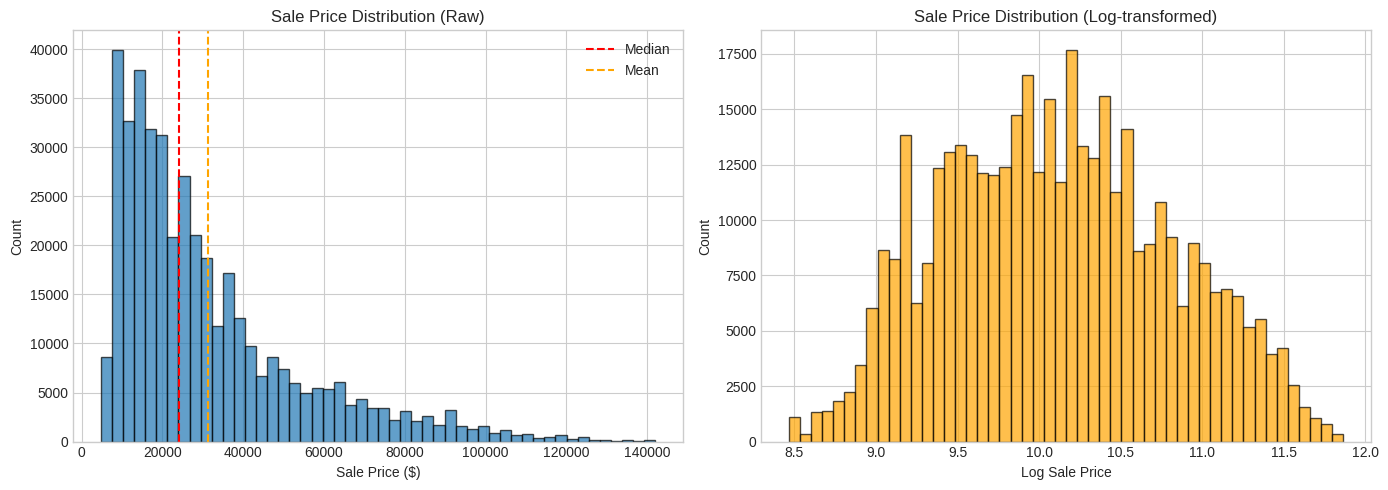

The log transformation makes the distribution much more symmetric - this helps our models!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw prices - heavily skewed to the right
axes[0].hist(bulldozer_data['SalePrice'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(bulldozer_data['SalePrice'].median(), color='red', linestyle='--', label='Median')
axes[0].axvline(bulldozer_data['SalePrice'].mean(), color='orange', linestyle='--', label='Mean')
axes[0].set_xlabel('Sale Price ($)')
axes[0].set_ylabel('Count')
axes[0].set_title('Sale Price Distribution (Raw)')
axes[0].legend()

# Log prices - much more symmetric!
axes[1].hist(np.log(bulldozer_data['SalePrice']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Log Sale Price')
axes[1].set_ylabel('Count')
axes[1].set_title('Sale Price Distribution (Log-transformed)')

plt.tight_layout()
plt.show()

print("The log transformation makes the distribution much more symmetric - this helps our models!")

### What Affects Price?

Before we build any models, let's explore which features seem to affect price. This will help us build intuition for how tree-based models think about the data.

The core idea behind decision trees is simple: **split the data based on one feature, and check if the two groups have different average prices**. Let's try that manually with a few features.

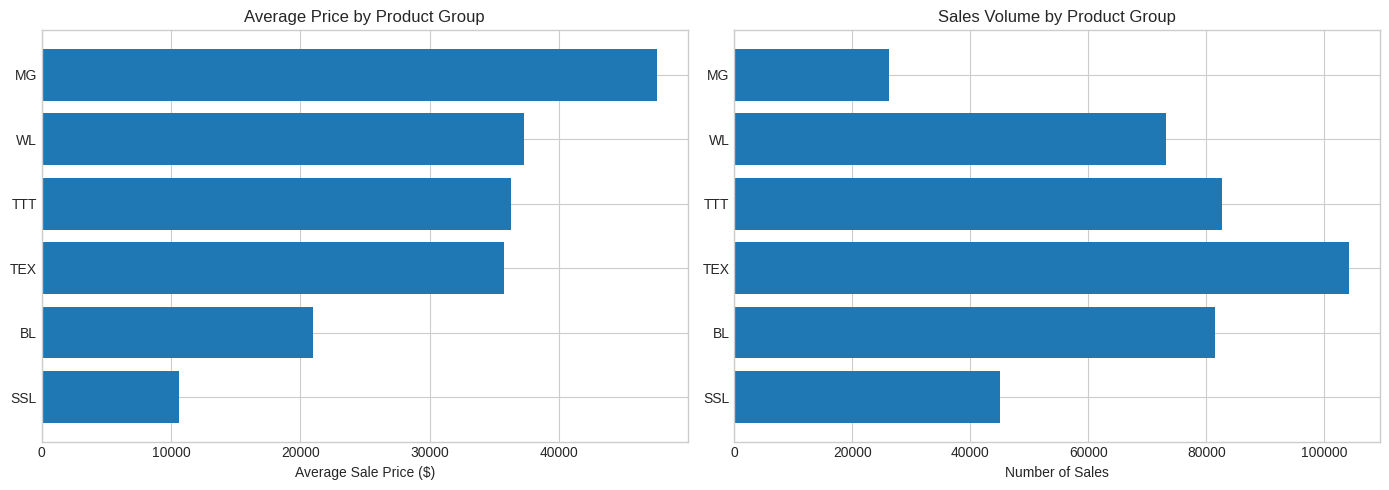

WL = Wheel Loader, TEX = Track Excavator, BL = Backhoe Loader, etc.

Track Excavators (TEX) sell for the most on average!


In [6]:
# Let's look at how product type affects price
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# What are the different product groups?
price_by_group = bulldozer_data.groupby('ProductGroup')['SalePrice'].agg(['mean', 'count'])
price_by_group = price_by_group.sort_values('mean', ascending=True)

axes[0].barh(price_by_group.index, price_by_group['mean'])
axes[0].set_xlabel('Average Sale Price ($)')
axes[0].set_title('Average Price by Product Group')

axes[1].barh(price_by_group.index, price_by_group['count'])
axes[1].set_xlabel('Number of Sales')
axes[1].set_title('Sales Volume by Product Group')

plt.tight_layout()
plt.show()

print("WL = Wheel Loader, TEX = Track Excavator, BL = Backhoe Loader, etc.")
print("\nTrack Excavators (TEX) sell for the most on average!")

That's a categorical feature. What about a continuous one like the year the equipment was made?

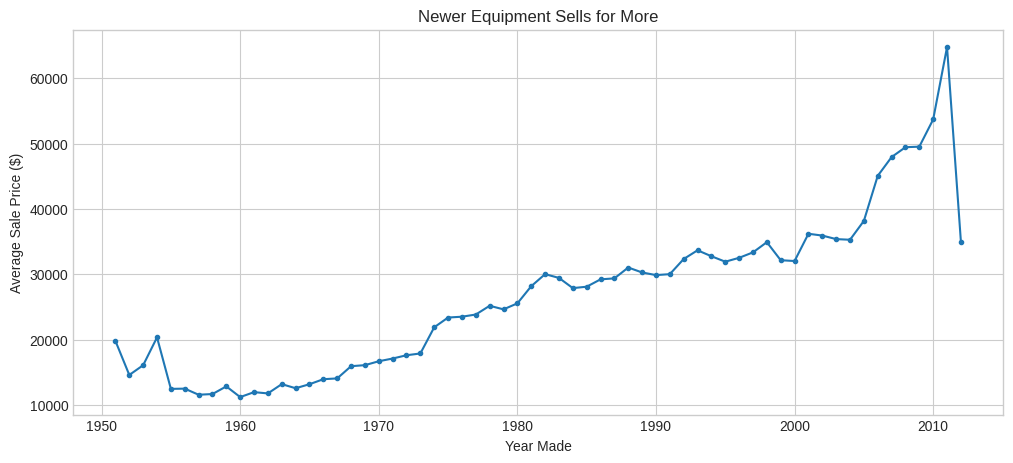

Makes sense! Newer equipment is worth more.
A tree might split on YearMade > 2000 to separate 'newer' from 'older' equipment.


In [7]:
# Filter out obviously wrong years (there are some 1000 values in the data!)
valid_years = bulldozer_data[(bulldozer_data['YearMade'] > 1950) & (bulldozer_data['YearMade'] <= 2012)]

fig, ax = plt.subplots(figsize=(12, 5))

# Average price by year made
price_by_year = valid_years.groupby('YearMade')['SalePrice'].mean()
ax.plot(price_by_year.index, price_by_year.values, marker='o', markersize=3)
ax.set_xlabel('Year Made')
ax.set_ylabel('Average Sale Price ($)')
ax.set_title('Newer Equipment Sells for More')
plt.show()

print("Makes sense! Newer equipment is worth more.")
print("A tree might split on YearMade > 2000 to separate 'newer' from 'older' equipment.")

## How Binary Splits Work

This is the fundamental building block of all tree-based models. A **binary split** divides data into two groups based on a single question: "Is this feature value above or below some threshold?"

Consider splitting bulldozers on YearMade at the year 2000:

In [8]:
# Perform a binary split on YearMade
older_equipment = bulldozer_data[bulldozer_data['YearMade'] <= 2000]
newer_equipment = bulldozer_data[bulldozer_data['YearMade'] > 2000]

print(f"Older equipment (made ≤ 2000):")
print(f"  Count: {len(older_equipment):,}")
print(f"  Average price: ${older_equipment['SalePrice'].mean():,.0f}")

print(f"\nNewer equipment (made > 2000):")
print(f"  Count: {len(newer_equipment):,}")
print(f"  Average price: ${newer_equipment['SalePrice'].mean():,.0f}")

print(f"\nThe split separates equipment into groups with different price characteristics.")

Older equipment (made ≤ 2000):
  Count: 308,699
  Average price: $28,844

Newer equipment (made > 2000):
  Count: 103,999
  Average price: $38,253

The split separates equipment into groups with different price characteristics.


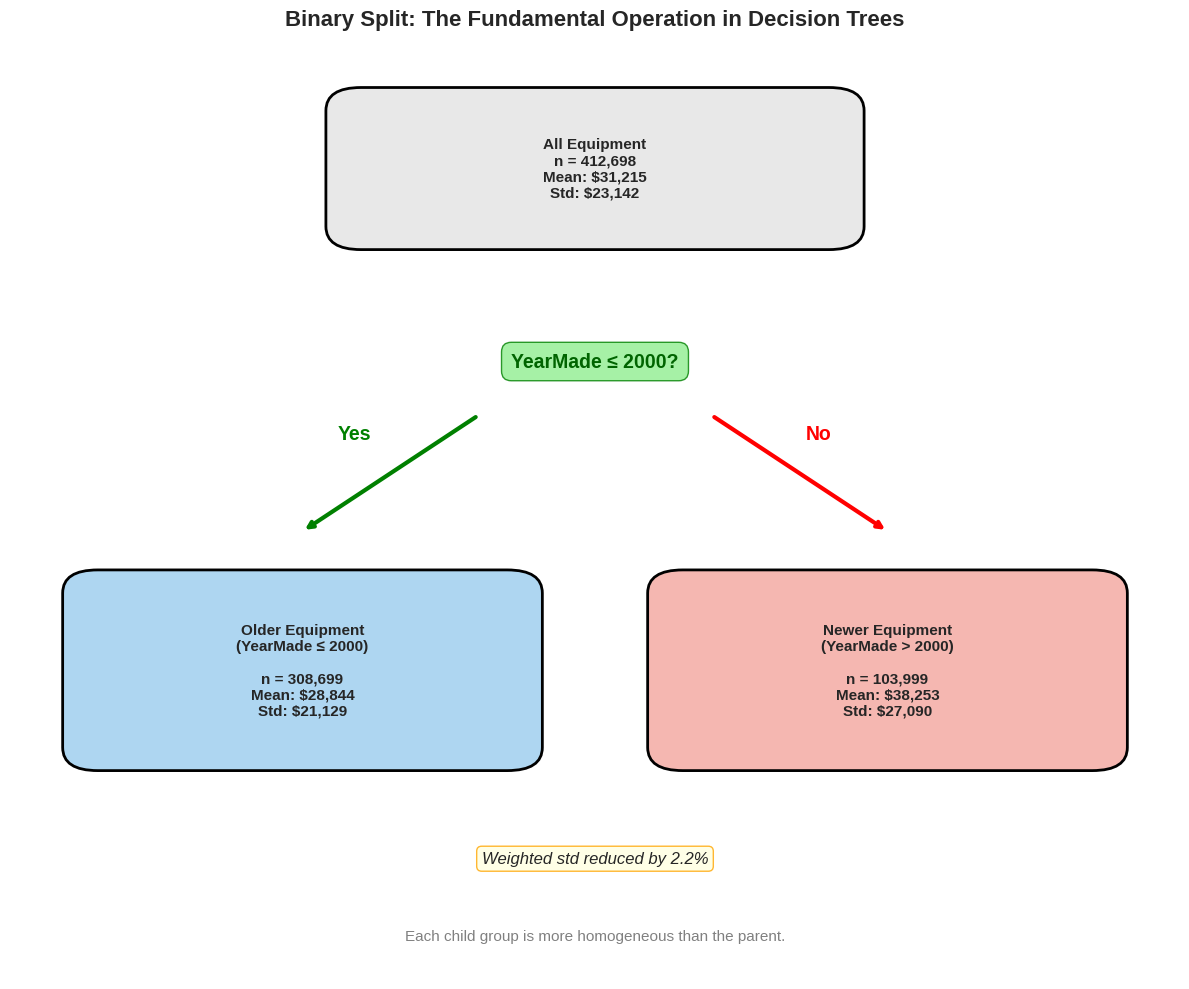

In [9]:
# Visualizing the binary split as a tree diagram
fig, ax = plt.subplots(figsize=(12, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

def draw_node(ax, x, y, width, height, text, color='lightblue'):
    from matplotlib.patches import FancyBboxPatch
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                          boxstyle="round,pad=0.05,rounding_size=0.3",
                          facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=11, fontweight='bold')

# Calculate statistics
total_n = len(bulldozer_data)
total_mean = bulldozer_data['SalePrice'].mean()
total_std = bulldozer_data['SalePrice'].std()

old_n = len(older_equipment)
old_mean = older_equipment['SalePrice'].mean()
old_std = older_equipment['SalePrice'].std()

new_n = len(newer_equipment)
new_mean = newer_equipment['SalePrice'].mean()
new_std = newer_equipment['SalePrice'].std()

# Root node
draw_node(ax, 5, 10.5, 4.5, 2, 
          f"All Equipment\nn = {total_n:,}\nMean: ${total_mean:,.0f}\nStd: ${total_std:,.0f}", 
          color='#E8E8E8')

# Split condition
ax.text(5, 8, "YearMade ≤ 2000?", ha='center', va='center', fontsize=14, 
        fontweight='bold', color='darkgreen',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', edgecolor='green', alpha=0.8))

# Arrows
ax.annotate('', xy=(2.5, 5.8), xytext=(4, 7.3),
            arrowprops=dict(arrowstyle='->', color='green', lw=3))
ax.annotate('', xy=(7.5, 5.8), xytext=(6, 7.3),
            arrowprops=dict(arrowstyle='->', color='red', lw=3))

ax.text(2.8, 7, "Yes", fontsize=14, color='green', fontweight='bold')
ax.text(6.8, 7, "No", fontsize=14, color='red', fontweight='bold')

# Child nodes
draw_node(ax, 2.5, 4, 4, 2.5, 
          f"Older Equipment\n(YearMade ≤ 2000)\n\nn = {old_n:,}\nMean: ${old_mean:,.0f}\nStd: ${old_std:,.0f}", 
          color='#AED6F1')

draw_node(ax, 7.5, 4, 4, 2.5,
          f"Newer Equipment\n(YearMade > 2000)\n\nn = {new_n:,}\nMean: ${new_mean:,.0f}\nStd: ${new_std:,.0f}",
          color='#F5B7B1')

# Variance reduction annotation
variance_reduction = ((total_std - (old_std * old_n/total_n + new_std * new_n/total_n)) / total_std) * 100
ax.text(5, 1.5, f"Weighted std reduced by {variance_reduction:.1f}%", 
        ha='center', fontsize=12, style='italic',
        bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange', alpha=0.8))
ax.text(5, 0.5, "Each child group is more homogeneous than the parent.", 
        ha='center', fontsize=11, color='gray')

plt.title('Binary Split: The Fundamental Operation in Decision Trees', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

How do we know if a split is *good*? A good split creates groups that are internally homogeneous - meaning the prices within each group should be similar to each other.

**Impurity** measures how spread out the values are within a group. For regression, we use standard deviation:
- Low std → prices are similar (pure group, good!)  
- High std → prices vary widely (impure group, bad!)

The following function calculates a split's quality by computing the weighted standard deviation of both groups:

In [10]:
def calculate_split_score(feature_column, target, split_value):
    """
    Calculate split quality. Lower score = better split.
    
    Uses weighted standard deviation of each group.
    Weighting by group size ensures larger groups matter more.
    """
    left_mask = feature_column <= split_value
    right_mask = ~left_mask
    
    left_std = target[left_mask].std() if left_mask.sum() > 1 else 0
    right_std = target[right_mask].std() if right_mask.sum() > 1 else 0
    
    # Weight by group size
    left_weight = left_mask.sum() / len(target)
    right_weight = right_mask.sum() / len(target)
    
    return left_std * left_weight + right_std * right_weight

# Testing different split points for YearMade
for year in [1990, 1995, 2000, 2005]:
    score = calculate_split_score(
        bulldozer_data['YearMade'], 
        bulldozer_data['SalePrice'], 
        year
    )
    print(f"Split at YearMade ≤ {year}: score = {score:,.0f}")

Split at YearMade ≤ 1990: score = 22,417
Split at YearMade ≤ 1995: score = 22,537
Split at YearMade ≤ 2000: score = 22,631
Split at YearMade ≤ 2005: score = 22,814


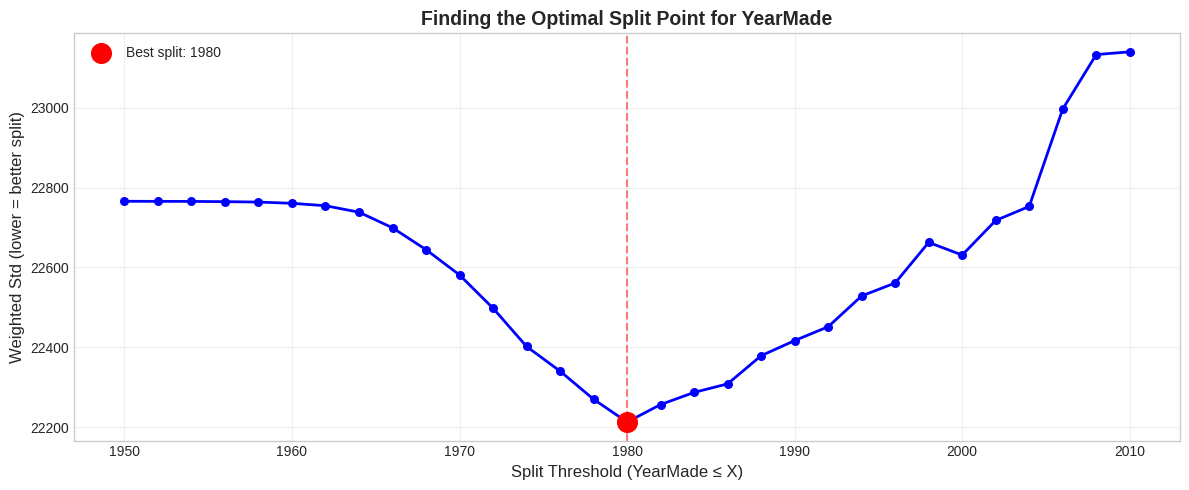

The tree algorithm tests every possible threshold and selects the one with lowest score.
For YearMade, the optimal split is at 1980.


In [11]:
# Visualizing how split score varies across different thresholds

years_to_try = range(1950, 2012, 2)
scores = []

for year in years_to_try:
    score = calculate_split_score(
        bulldozer_data['YearMade'], 
        bulldozer_data['SalePrice'], 
        year
    )
    scores.append(score)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(list(years_to_try), scores, 'b-', linewidth=2)
ax.scatter(list(years_to_try), scores, c='blue', s=30)

# Mark the best split
best_idx = scores.index(min(scores))
best_year_viz = list(years_to_try)[best_idx]
ax.scatter([best_year_viz], [min(scores)], c='red', s=200, zorder=5, label=f'Best split: {best_year_viz}')
ax.axvline(best_year_viz, color='red', linestyle='--', alpha=0.5)

ax.set_xlabel('Split Threshold (YearMade ≤ X)', fontsize=12)
ax.set_ylabel('Weighted Std (lower = better split)', fontsize=12)
ax.set_title('Finding the Optimal Split Point for YearMade', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"The tree algorithm tests every possible threshold and selects the one with lowest score.")
print(f"For YearMade, the optimal split is at {best_year_viz}.")

The curve shows that splitting around 1995-2005 produces the lowest weighted standard deviation. The tree algorithm performs this search automatically for every feature, then picks the overall best split.

**Classification vs Regression**

The tree-building algorithm is identical for both tasks. Only the scoring function differs:

| Task | Scoring | What it measures |
|------|---------|------------------|
| **Regression** | Variance / Std | How spread out are the values? |
| **Classification** | Gini impurity | How mixed are the classes? |

Since this dataset involves predicting prices (continuous values), we use variance. For a classification task like Titanic survival prediction, Gini impurity would be used instead.

Optimal split for YearMade: ≤ 1980
Score: 22,212


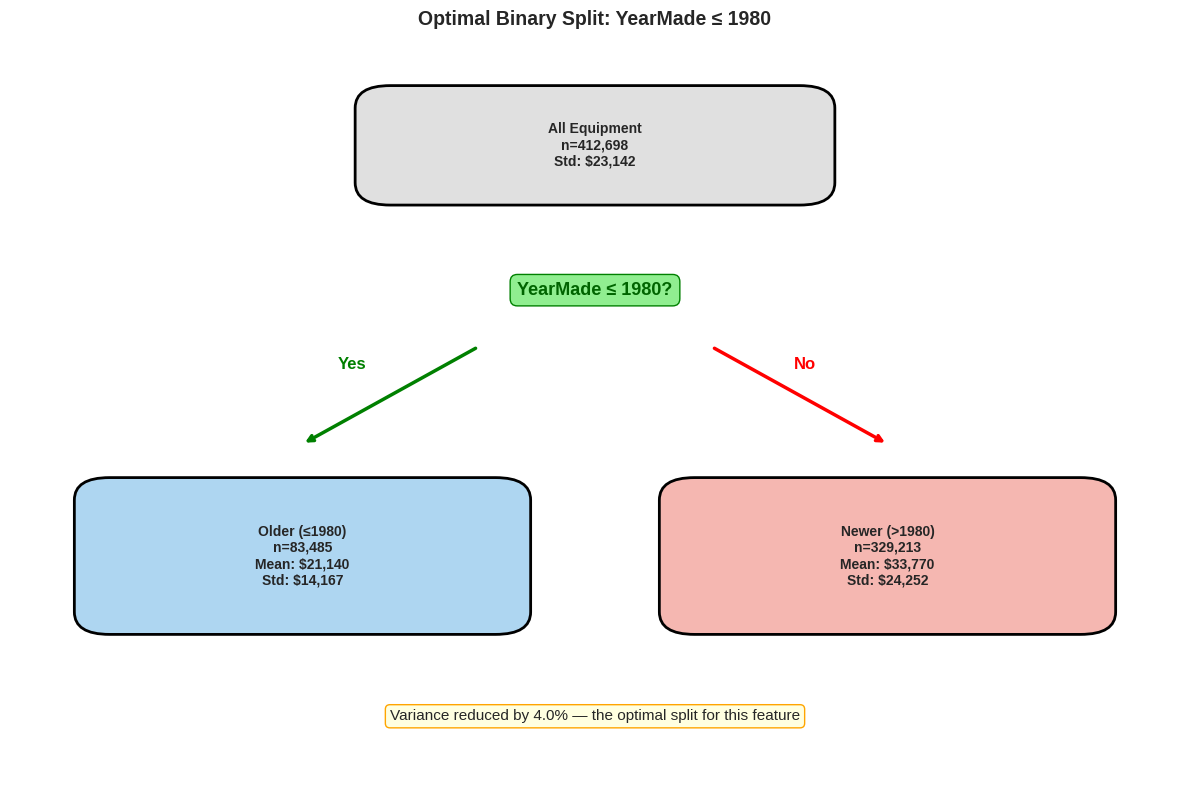

In [12]:
# Finding the optimal split point and visualizing the result

def find_best_split(feature_column, target):
    """Find the best split point for a single column."""
    unique_values = feature_column.dropna().unique()
    unique_values.sort()
    
    best_score = float('inf')
    best_split = None
    
    for value in unique_values:
        score = calculate_split_score(feature_column, target, value)
        if score < best_score:
            best_score = score
            best_split = value
    
    return best_split, best_score

best_year, best_score = find_best_split(bulldozer_data['YearMade'], bulldozer_data['SalePrice'])
print(f"Optimal split for YearMade: ≤ {best_year}")
print(f"Score: {best_score:,.0f}")

# Visualizing the optimal split as a tree diagram
fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

def draw_node(ax, x, y, w, h, text, color):
    from matplotlib.patches import FancyBboxPatch
    box = FancyBboxPatch((x-w/2, y-h/2), w, h, boxstyle="round,pad=0.05,rounding_size=0.3",
                          facecolor=color, edgecolor='black', linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=10, fontweight='bold')

# Calculate statistics for the optimal split
left = bulldozer_data[bulldozer_data['YearMade'] <= best_year]
right = bulldozer_data[bulldozer_data['YearMade'] > best_year]
total_std = bulldozer_data['SalePrice'].std()

# Root
draw_node(ax, 5, 8.5, 4, 1.5, f"All Equipment\nn={len(bulldozer_data):,}\nStd: ${total_std:,.0f}", '#E0E0E0')

# Split condition
ax.text(5, 6.5, f"YearMade ≤ {best_year}?", ha='center', fontsize=13, fontweight='bold', color='darkgreen',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#90EE90', edgecolor='green'))

# Arrows
ax.annotate('', xy=(2.5, 4.5), xytext=(4, 5.8), arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
ax.annotate('', xy=(7.5, 4.5), xytext=(6, 5.8), arrowprops=dict(arrowstyle='->', color='red', lw=2.5))
ax.text(2.8, 5.5, "Yes", fontsize=12, color='green', fontweight='bold')
ax.text(6.7, 5.5, "No", fontsize=12, color='red', fontweight='bold')

# Children
draw_node(ax, 2.5, 3, 3.8, 2, f"Older (≤{best_year})\nn={len(left):,}\nMean: ${left['SalePrice'].mean():,.0f}\nStd: ${left['SalePrice'].std():,.0f}", '#AED6F1')
draw_node(ax, 7.5, 3, 3.8, 2, f"Newer (>{best_year})\nn={len(right):,}\nMean: ${right['SalePrice'].mean():,.0f}\nStd: ${right['SalePrice'].std():,.0f}", '#F5B7B1')

# Variance reduction
weighted_std = (left['SalePrice'].std() * len(left) + right['SalePrice'].std() * len(right)) / len(bulldozer_data)
reduction = (total_std - weighted_std) / total_std * 100
ax.text(5, 0.8, f"Variance reduced by {reduction:.1f}% — the optimal split for this feature", 
        ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))

plt.title(f'Optimal Binary Split: YearMade ≤ {best_year}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### From Manual Splits to Automated Trees

The process above - testing thresholds, computing scores, selecting the best - is exactly what sklearn's `DecisionTreeRegressor` does automatically. It also chains multiple splits together, creating a full tree structure.

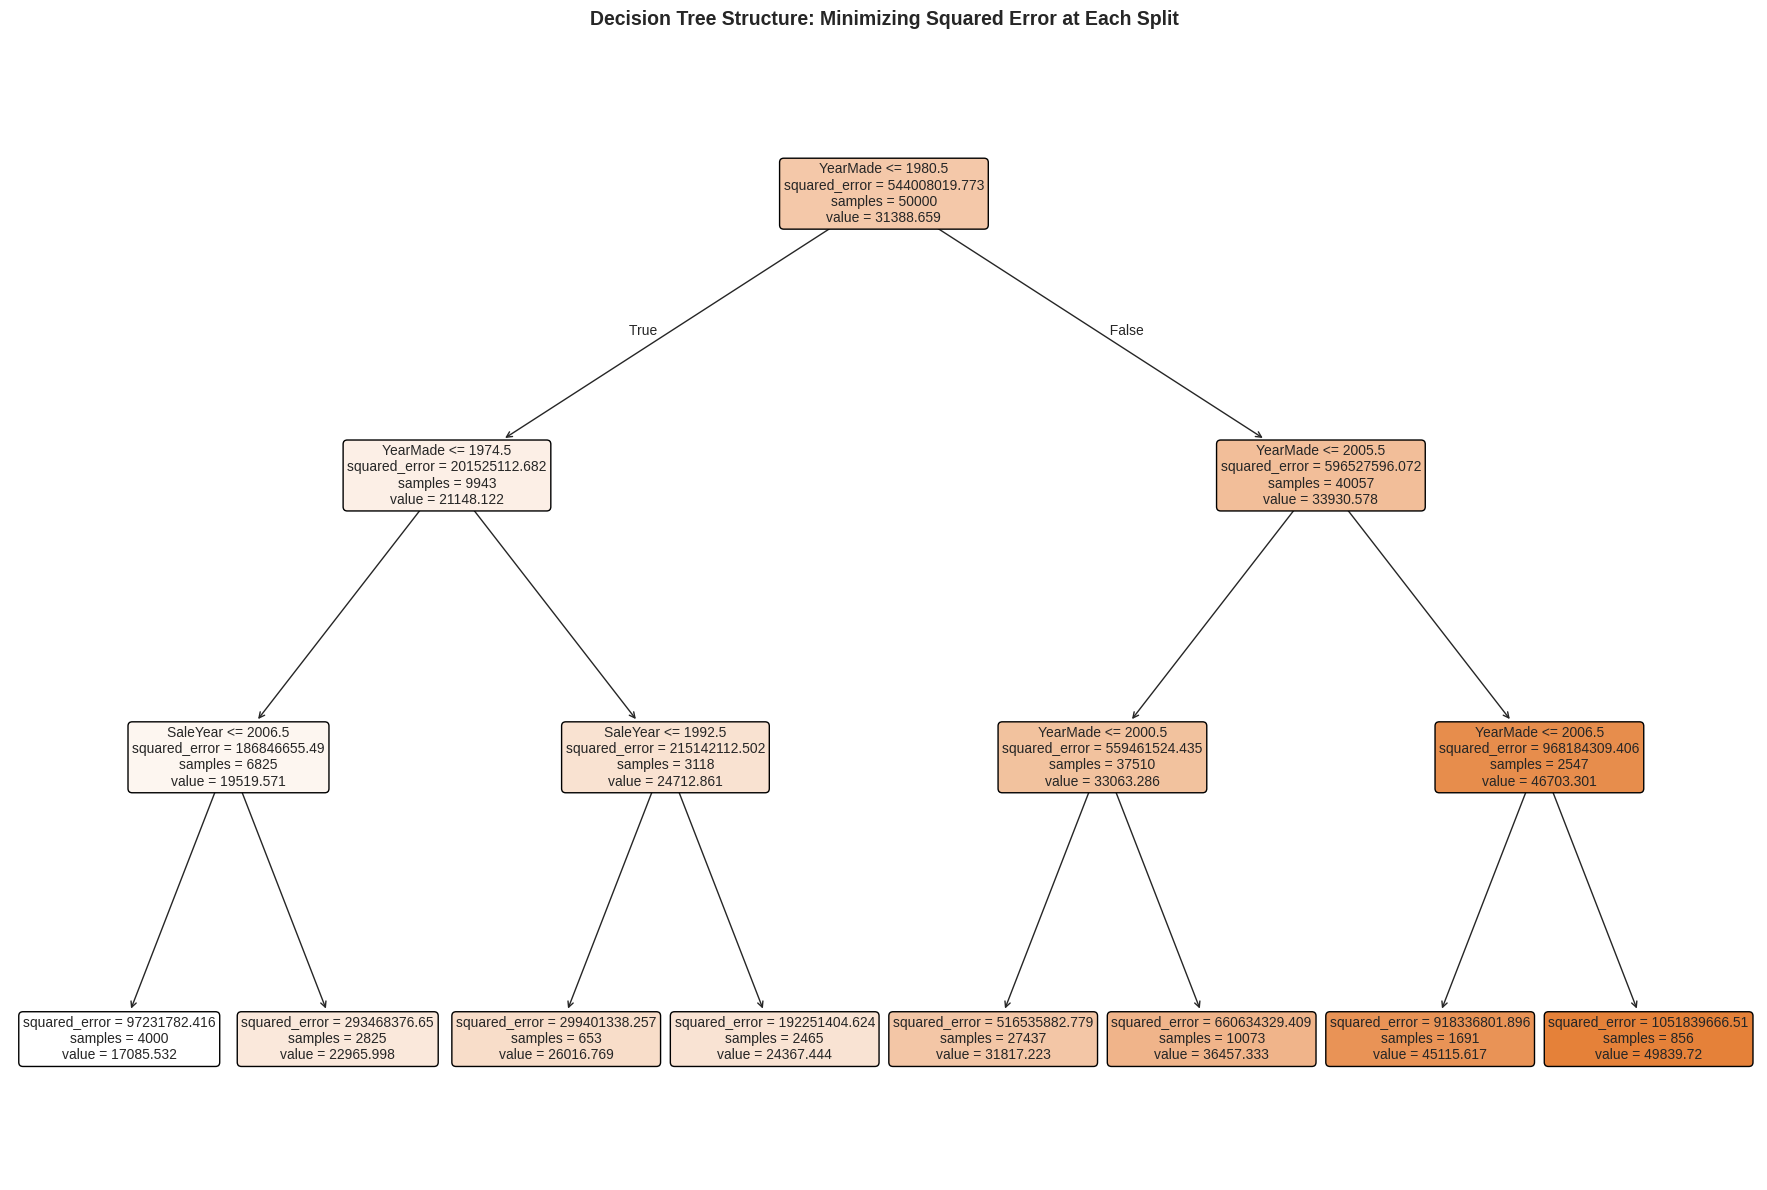

Reading the tree:
  • squared_error = variance of prices in that node (lower = more homogeneous)
  • samples = number of training examples in the node
  • value = mean price (the prediction for samples reaching this node)

This tree has 8 leaves, each producing a distinct prediction.


In [13]:
# Training a real decision tree with sklearn
# This demonstrates how the algorithm chains multiple splits automatically

from sklearn.tree import DecisionTreeRegressor, plot_tree

# Prepare sample data
sample_size = 50000
sample_idx = np.random.choice(len(bulldozer_data), size=min(sample_size, len(bulldozer_data)), replace=False)
sample_data = bulldozer_data.iloc[sample_idx].copy()

sample_data = sample_data.dropna(subset=['YearMade', 'SalePrice'])
sample_data['sale_year'] = sample_data['saledate'].dt.year

X_demo = sample_data[['YearMade', 'sale_year']].fillna(0)
y_demo = sample_data['SalePrice']

# Train a small tree (limited depth for visualization)
small_tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=500, random_state=42)
small_tree.fit(X_demo, y_demo)

# Visualize the tree structure
# squared_error is the regression equivalent of Gini - it's what the tree minimizes
fig, ax = plt.subplots(figsize=(18, 12))
plot_tree(small_tree, 
          feature_names=['YearMade', 'SaleYear'],
          filled=True,
          rounded=True,
          fontsize=10,
          ax=ax,
          impurity=True)

plt.title('Decision Tree Structure: Minimizing Squared Error at Each Split', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("Reading the tree:")
print("  • squared_error = variance of prices in that node (lower = more homogeneous)")
print("  • samples = number of training examples in the node")
print("  • value = mean price (the prediction for samples reaching this node)")
print(f"\nThis tree has {small_tree.get_n_leaves()} leaves, each producing a distinct prediction.")

### How Many Predictions Can a Tree Make?

An important property to understand: a tree's prediction is always the **mean value of training samples in that leaf**. This means the number of distinct predictions equals the number of leaves.

Tree structure:
  Depth: 3
  Leaves: 8
  Unique prediction values: 8

All possible outputs from this tree:
  $17,086  →  assigned to 4,000 samples
  $22,966  →  assigned to 2,825 samples
  $24,367  →  assigned to 2,465 samples
  $26,017  →  assigned to 653 samples
  $31,817  →  assigned to 27,437 samples
  $36,457  →  assigned to 10,073 samples
  $45,116  →  assigned to 1,691 samples
  $49,840  →  assigned to 856 samples


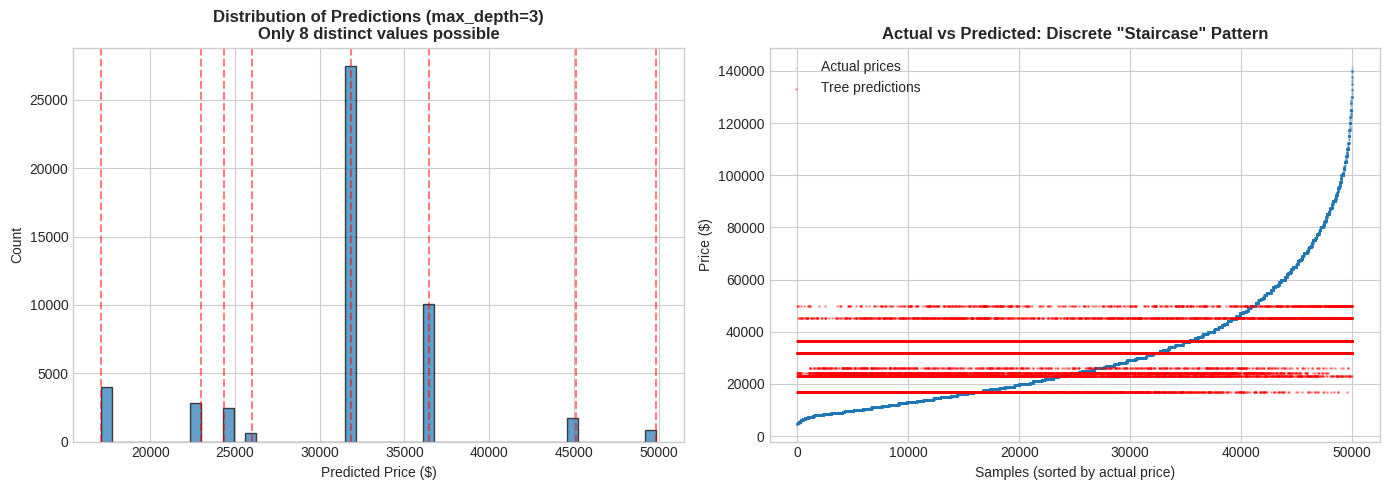

In [14]:
# A decision tree can only output as many distinct values as it has leaves.
# This is a fundamental property worth understanding.

predictions = small_tree.predict(X_demo)
unique_predictions = np.unique(predictions)

print(f"Tree structure:")
print(f"  Depth: {small_tree.get_depth()}")
print(f"  Leaves: {small_tree.get_n_leaves()}")
print(f"  Unique prediction values: {len(unique_predictions)}")
print(f"\nAll possible outputs from this tree:")
for i, pred in enumerate(sorted(unique_predictions), 1):
    count = (predictions == pred).sum()
    print(f"  ${pred:,.0f}  →  assigned to {count:,} samples")

# Visualizing the discrete nature of tree predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram showing predictions cluster at discrete values
axes[0].hist(predictions, bins=50, edgecolor='black', alpha=0.7)
for pred in unique_predictions:
    axes[0].axvline(pred, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Distribution of Predictions (max_depth=3)\nOnly {len(unique_predictions)} distinct values possible', fontweight='bold')

# Right: actual vs predicted shows the "staircase" pattern
sorted_idx = np.argsort(y_demo.values)
axes[1].scatter(range(len(y_demo)), y_demo.values[sorted_idx], alpha=0.1, s=1, label='Actual prices')
axes[1].scatter(range(len(predictions)), predictions[sorted_idx], alpha=0.3, s=1, color='red', label='Tree predictions')
axes[1].set_xlabel('Samples (sorted by actual price)')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Actual vs Predicted: Discrete "Staircase" Pattern', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

This discrete output is a key characteristic of decision trees. With only 8 leaves, thousands of different bulldozers get binned into just 8 price buckets. What happens with deeper trees?

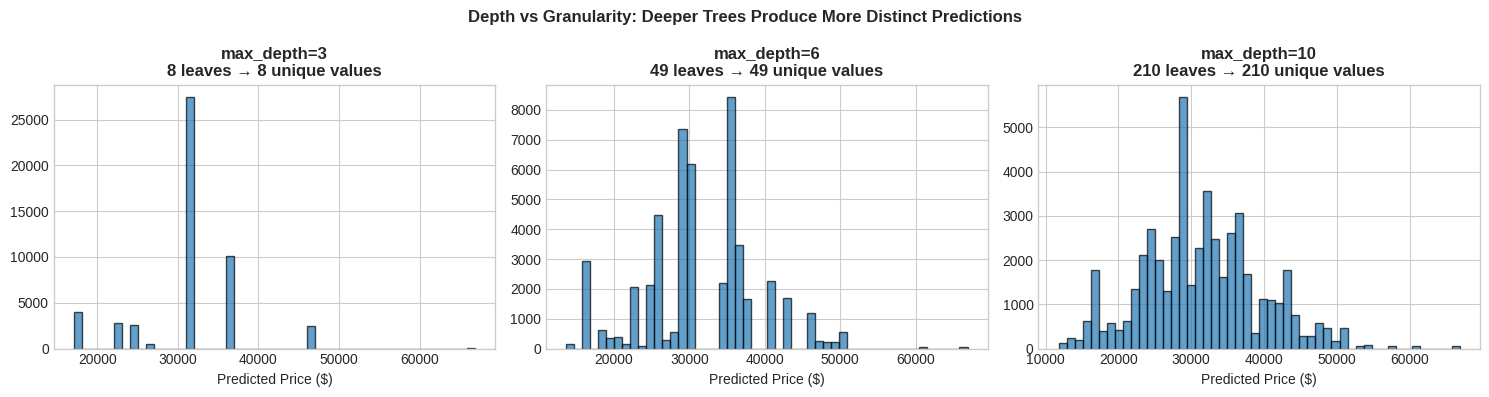

The tradeoff:
  • Shallow trees → few prediction values, coarse but stable
  • Deep trees → many prediction values, fine-grained but prone to overfitting

Random forests address this by averaging many deep trees together.


In [15]:
# The relationship between tree depth and prediction granularity

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, depth in enumerate([3, 6, 10]):
    tree = DecisionTreeRegressor(max_depth=depth, min_samples_leaf=50, random_state=42)
    tree.fit(X_demo, y_demo)
    preds = tree.predict(X_demo)
    
    axes[idx].hist(preds, bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'max_depth={depth}\n{tree.get_n_leaves()} leaves → {len(np.unique(preds))} unique values', 
                        fontweight='bold')
    axes[idx].set_xlabel('Predicted Price ($)')

plt.suptitle('Depth vs Granularity: Deeper Trees Produce More Distinct Predictions', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("The tradeoff:")
print("  • Shallow trees → few prediction values, coarse but stable")
print("  • Deep trees → many prediction values, fine-grained but prone to overfitting")
print("\nRandom forests address this by averaging many deep trees together.")

This depth-granularity tradeoff is fundamental. Random forests solve it by averaging many deep trees together - each tree overfits differently, but the average is stable.

## From Binary Splits to Decision Trees

A single binary split divides data into two groups. But within each group, there's still variation - some older equipment sells for much more than other older equipment.

A **decision tree** addresses this by splitting recursively:
1. Split all data on the best feature/threshold
2. For each resulting group, find its best split
3. Repeat until a stopping condition (max depth, min samples per leaf)

Each path through the tree represents a series of conditions, and each leaf contains a prediction (the mean of training samples that reached it).

Before building trees on this data, understanding its structure is essential. The following exploration reveals characteristics that will affect how trees learn.

### Missing Data

Real-world datasets are rarely complete. Equipment details may not be recorded, auction records could be incomplete, or certain fields may not apply to all equipment types.

In [16]:
missing_percentages = (bulldozer_data.isnull().sum() / len(bulldozer_data) * 100).sort_values(ascending=False)
missing_with_values = missing_percentages[missing_percentages > 0]

print(f"Columns with missing values: {len(missing_with_values)}")
print("\nTop 15 columns by missing percentage:")
print(missing_with_values.head(15).round(1))

Columns with missing values: 40

Top 15 columns by missing percentage:
Pushblock            93.7
Tip_Control          93.7
Enclosure_Type       93.7
Engine_Horsepower    93.7
Blade_Extension      93.7
Blade_Width          93.7
Scarifier            93.7
Grouser_Tracks       89.1
Hydraulics_Flow      89.1
Coupler_System       89.1
fiModelSeries        85.8
Steering_Controls    82.7
Differential_Type    82.7
UsageBand            82.1
fiModelDescriptor    81.9
dtype: float64


Several features have substantial missing values - `Blade_Extension` exceeds 90%. This likely reflects that certain features only apply to specific equipment types rather than data quality issues.

Tree-based models handle missing values reasonably well, which is one of their practical advantages over neural networks.

In [17]:
print("Data types:")
print(bulldozer_data.dtypes.value_counts())

print("\nObject (categorical) columns:")
object_columns = bulldozer_data.select_dtypes(include=['object']).columns.tolist()
print(object_columns)

Data types:
object            44
int64              5
float64            3
datetime64[ns]     1
Name: count, dtype: int64

Object (categorical) columns:
['UsageBand', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries', 'fiModelDescriptor', 'ProductSize', 'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc', 'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control', 'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension', 'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics', 'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size', 'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow', 'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb', 'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type', 'Travel_Controls', 'Differential_Type', 'Steering_Controls']


The dataset contains a mix of numeric and categorical (object) columns. The categorical columns will need conversion to integer codes before modeling.

### Temporal Structure

This dataset spans multiple years of auction sales. Equipment prices and market conditions evolve over time, making the temporal dimension critical for proper model evaluation.

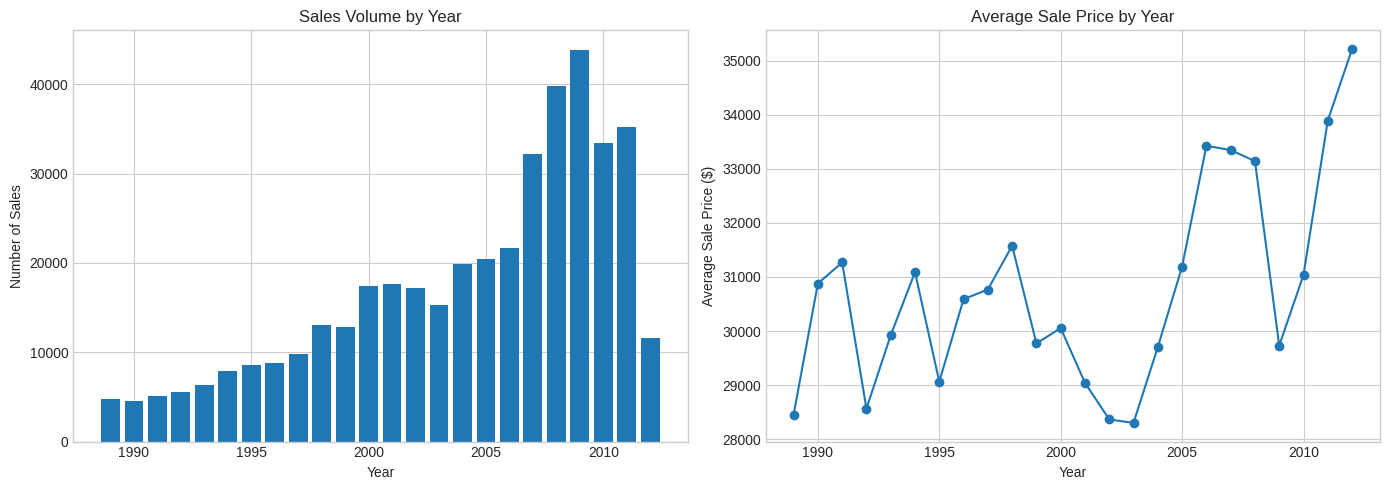

In [18]:
sales_by_year = bulldozer_data.groupby(bulldozer_data['saledate'].dt.year)['SalePrice'].agg(['mean', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(sales_by_year.index, sales_by_year['count'])
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Sales')
axes[0].set_title('Sales Volume by Year')

axes[1].plot(sales_by_year.index, sales_by_year['mean'], marker='o')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average Sale Price ($)')
axes[1].set_title('Average Sale Price by Year')

plt.tight_layout()
plt.show()

The sales volume and average price both vary substantially by year. Economic cycles are visible in the data - periods of reduced activity and lower prices followed by recovery.

This temporal pattern has an important implication: the train/validation split must respect time. Training on future data to predict the past would create unrealistic performance estimates that won't hold in deployment.

### Categorical Features

Categorical variables require conversion to numeric codes for tree algorithms. Understanding their cardinality (number of unique values) helps determine preprocessing strategy.

In [19]:
# Examine cardinality of categorical columns
for col in ['ProductGroup', 'state', 'fiProductClassDesc']:
    print(f"\n{col}:")
    print(bulldozer_data[col].value_counts().head(10))


ProductGroup:
ProductGroup
TEX    104230
TTT     82582
BL      81401
WL      73216
SSL     45011
MG      26258
Name: count, dtype: int64

state:
state
Florida        67320
Texas          53110
California     29761
Washington     16222
Georgia        14633
Maryland       13322
Mississippi    13240
Ohio           12369
Illinois       11540
Colorado       11529
Name: count, dtype: int64

fiProductClassDesc:
fiProductClassDesc
Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth    57542
Track Type Tractor, Dozer - 20.0 to 75.0 Horsepower        18131
Wheel Loader - 150.0 to 175.0 Horsepower                   15537
Track Type Tractor, Dozer - 85.0 to 105.0 Horsepower       15161
Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons      13736
Track Type Tractor, Dozer - 130.0 to 160.0 Horsepower      11530
Hydraulic Excavator, Track - 12.0 to 14.0 Metric Tons      11527
Track Type Tractor, Dozer - 260.0 + Horsepower             11227
Wheel Loader - 120.0 to 135.0 Horsepower            

`ProductGroup` has low cardinality (6 values), while `fiProductClassDesc` has many specific descriptions. The `state` distribution shows Texas, Florida, and California dominating - states with significant construction activity.

The mix of low and high cardinality categorical features is typical of real tabular datasets.

In [20]:
numeric_columns = bulldozer_data.select_dtypes(include=[np.number]).columns.tolist()
numeric_columns.remove('SalePrice')  # Exclude target

print(f"Numeric features: {len(numeric_columns)}")
bulldozer_data[numeric_columns].describe()

Numeric features: 7


,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter
count,4.126980e+05,4.126980e+05,412698.000000,412698.000000,392562.000000,412698.000000,1.475040e+05
mean,2.011161e+06,1.230061e+06,6947.201828,135.169361,6.585268,1899.049637,3.522988e+03
std,1.080068e+06,4.539533e+05,6280.824982,9.646749,17.158409,292.190243,2.716993e+04
min,1.139246e+06,0.000000e+00,28.000000,121.000000,0.000000,1000.000000,0.000000e+00
25%,1.421898e+06,1.088593e+06,3261.000000,132.000000,1.000000,1985.000000,0.000000e+00
50%,1.645852e+06,1.284397e+06,4605.000000,132.000000,2.000000,1995.000000,0.000000e+00
75%,2.261012e+06,1.478079e+06,8899.000000,136.000000,4.000000,2001.000000,3.209000e+03
max,6.333349e+06,2.486330e+06,37198.000000,173.000000,99.000000,2014.000000,2.483300e+06


## Data Preprocessing

Tree-based models require minimal preprocessing compared to neural networks:
- **No normalization needed** - trees only care about feature order, not scale
- **Missing values handled gracefully** - trees can learn to route missing values
- **No one-hot encoding required** - integer codes work directly

The preprocessing steps that remain:
1. Extract useful components from date columns
2. Convert categorical strings to integer codes
3. Fill missing values with a consistent strategy
4. Create a time-based train/validation split

### Extracting Date Features

Our `saledate` column contains datetime values, but trees can't directly use dates. We need to extract meaningful components that trees can work with. 

Think about what might affect equipment prices seasonally or over time:
- **Month and day of week**: Maybe auctions on certain days get more bidders?
- **Year**: Prices trend upward over time (inflation, economic cycles)
- **Quarter**: Construction activity varies by season
- **Elapsed time**: A continuous number we can use for trends

Here's a function that extracts all these components:

### Categorical Encoding: Why Integer Codes Work for Trees

For neural networks, we typically use one-hot encoding (creating a separate 0/1 column for each category). But for trees, we can just convert categories to integer codes - it's simpler and more memory efficient.

Why does this work? Remember, trees only care about *order*. When a tree splits on a categorical feature like "state", it's asking "is the state code <= some threshold?" The tree will try all possible thresholds and find the one that best separates high-price from low-price equipment. 

Even though the numbers we assign to states (Texas=0, Florida=1, etc.) are arbitrary, the tree will find the right groupings. If Texas and California equipment tends to sell for more, the tree will learn to group those states together through its splits.

The one catch: this approach works best when the number of categories isn't too large. With thousands of categories, trees can overfit to specific category values.

In [21]:
def add_date_features(dataframe, date_column):
    """
    Extract useful features from a datetime column.
    Trees can't extrapolate, so we extract components that repeat (seasonality)
    plus an elapsed time feature for trends.
    """
    date_series = dataframe[date_column]
    
    dataframe[f'{date_column}_year'] = date_series.dt.year
    dataframe[f'{date_column}_month'] = date_series.dt.month
    dataframe[f'{date_column}_day'] = date_series.dt.day
    dataframe[f'{date_column}_dayofweek'] = date_series.dt.dayofweek
    dataframe[f'{date_column}_dayofyear'] = date_series.dt.dayofyear
    dataframe[f'{date_column}_quarter'] = date_series.dt.quarter
    dataframe[f'{date_column}_is_month_start'] = date_series.dt.is_month_start.astype(int)
    dataframe[f'{date_column}_is_month_end'] = date_series.dt.is_month_end.astype(int)
    dataframe[f'{date_column}_elapsed'] = date_series.astype(np.int64) // 10**9  # Unix timestamp
    
    # Keep the original date column for train/val split, drop it later
    return dataframe

bulldozer_processed = add_date_features(bulldozer_data.copy(), 'saledate')
print(f"Date features extracted. Shape: {bulldozer_processed.shape}")

Date features extracted. Shape: (412698, 62)


### Handling Missing Values

Trees can actually learn from the *pattern* of missingness. For example, if certain equipment specifications are only recorded for newer or more expensive machines, the fact that a value is missing could itself be informative.

For simplicity, we'll fill missing numeric values with the median (a robust choice that isn't affected by outliers), and missing categorical values with -1 (a "sentinel" value that the tree can learn to recognize). More sophisticated approaches exist, but these simple methods work surprisingly well for tree-based models.

In [22]:
def convert_to_category_codes(dataframe):
    """
    Convert object columns to category codes.
    Trees work with numeric values, and integer codes are efficient.
    """
    for column in dataframe.select_dtypes(include=['object']).columns:
        dataframe[column] = dataframe[column].astype('category').cat.codes
    return dataframe

bulldozer_processed = convert_to_category_codes(bulldozer_processed)
print(f"All columns now numeric: {bulldozer_processed.dtypes.unique()}")

All columns now numeric: [dtype('int64') dtype('float64') dtype('int8') dtype('<M8[ns]') dtype('int16') dtype('int32')]


We could use the mode (the most common value) when replacing nan values for categorical columns. But a sentinel value can work better sometimes. This is something one could tweak and test. 

In [23]:
# Handle missing values - trees can work with any fill strategy
def fill_missing_values(dataframe):
    """Fill missing values. Trees handle this well with any fill strategy."""
    for column in dataframe.columns:
        if dataframe[column].isnull().any():
            if dataframe[column].dtype in ['float64', 'int64']:
                dataframe[column] = dataframe[column].fillna(dataframe[column].median())
            else:
                dataframe[column] = dataframe[column].fillna(-1)  # Sentinel for categoricals
    return dataframe

bulldozer_processed = fill_missing_values(bulldozer_processed)
print(f"Missing values remaining: {bulldozer_processed.isnull().sum().sum()}")

Missing values remaining: 0


### Why Log-Transform the Target?

The Kaggle competition used RMSLE (Root Mean Squared Logarithmic Error) as the evaluation metric. There's a mathematical trick here: instead of computing RMSLE on raw prices, we can just take the log of prices and compute regular RMSE. The results are equivalent, but it's easier to work with.

Beyond the competition metric, there's another reason log-transforming makes sense. Equipment prices vary enormously - from $5,000 for a small used loader to $500,000 for a specialized excavator. A model that minimizes squared error on raw prices will focus all its attention on getting the expensive equipment right (because those errors are huge). Taking the log means we're optimizing for relative error instead, which is usually what we actually care about.

### Train/Validation Split: Time-Based

**For non-temporal data**, the standard approach is sklearn's `train_test_split`:
```python
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
```

**For temporal data like ours**, random splitting would leak future information into training. Instead, we split by date - training on the past to predict the future, which matches real-world deployment.

In [24]:
# Time-based split for temporal data
# Training: sales before 2012, Validation: sales from 2012 onwards

split_date = pd.Timestamp('2012-01-01')
train_data = bulldozer_processed[bulldozer_processed['saledate'] < split_date].copy()
validation_data = bulldozer_processed[bulldozer_processed['saledate'] >= split_date].copy()

# Drop the date column (features already extracted)
train_data = train_data.drop(columns=['saledate'])
validation_data = validation_data.drop(columns=['saledate'])

print(f"Training samples: {len(train_data):,} (before {split_date.strftime('%Y-%m-%d')})")
print(f"Validation samples: {len(validation_data):,} (from {split_date.strftime('%Y-%m-%d')})")
print(f"Validation ratio: {len(validation_data) / (len(train_data) + len(validation_data)):.1%}")

Training samples: 401,125 (before 2012-01-01)
Validation samples: 11,573 (from 2012-01-01)
Validation ratio: 2.8%


## Baseline Models

With preprocessing complete, we can train models. Starting with simple approaches establishes a baseline - if complex models barely beat a decision tree, something's wrong with the approach.

We'll build progressively:
1. **Single decision tree** - interpretable but limited
2. **Random forest** - ensemble that dramatically improves accuracy
3. **Analysis** - understanding what the model learned

In [25]:
target_column = 'SalePrice'

# Log-transform target for RMSLE optimization
# Taking RMSE on log prices is equivalent to RMSLE on raw prices
features_train = train_data.drop(columns=[target_column])
target_train = np.log(train_data[target_column])

features_validation = validation_data.drop(columns=[target_column])
target_validation = np.log(validation_data[target_column])

print(f"Training samples: {len(features_train):,}")
print(f"Validation samples: {len(features_validation):,}")
print(f"Number of features: {features_train.shape[1]}")

Training samples: 401,125
Validation samples: 11,573
Number of features: 60


In [26]:
def calculate_rmse(predictions, actual):
    """Calculate Root Mean Squared Error."""
    return np.sqrt(mean_squared_error(actual, predictions))

# Since we're working with log-transformed targets:
# RMSE on log values = RMSLE on original prices

### Single Decision Tree

A decision tree learns a series of if-then rules by recursively splitting data. We constrain it with `max_depth=4` (at most 4 levels of splits) and `min_samples_leaf=100` (leaves must have 100+ samples) to prevent overfitting and enable visualization.

In [27]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

single_tree = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=100,
    random_state=42
)
single_tree.fit(features_train, target_train)

tree_train_predictions = single_tree.predict(features_train)
tree_val_predictions = single_tree.predict(features_validation)

# Store for later comparison
tree_rmse = calculate_rmse(tree_val_predictions, target_validation)

print(f"Single Decision Tree Results:")
print(f"  Training RMSLE:   {calculate_rmse(tree_train_predictions, target_train):.4f}")
print(f"  Validation RMSLE: {tree_rmse:.4f}")
print(f"  Training R²:      {single_tree.score(features_train, target_train):.3f}")
print(f"  Validation R²:    {single_tree.score(features_validation, target_validation):.3f}")

Single Decision Tree Results:
  Training RMSLE:   0.4912
  Validation RMSLE: 0.5252
  Training R²:      0.498
  Validation R²:    0.489


**Reading the metrics:**
- **RMSLE ~0.52** means predictions are off by a factor of e^0.52 ≈ 1.68x on average
- **R² ~0.49** means the model explains about half the variance in prices
- **Train ≈ Validation** indicates no overfitting (the constraints worked)

R² of 0.49 is mediocre. The tree can only capture coarse patterns with just 16 possible outputs (2^4 leaves).

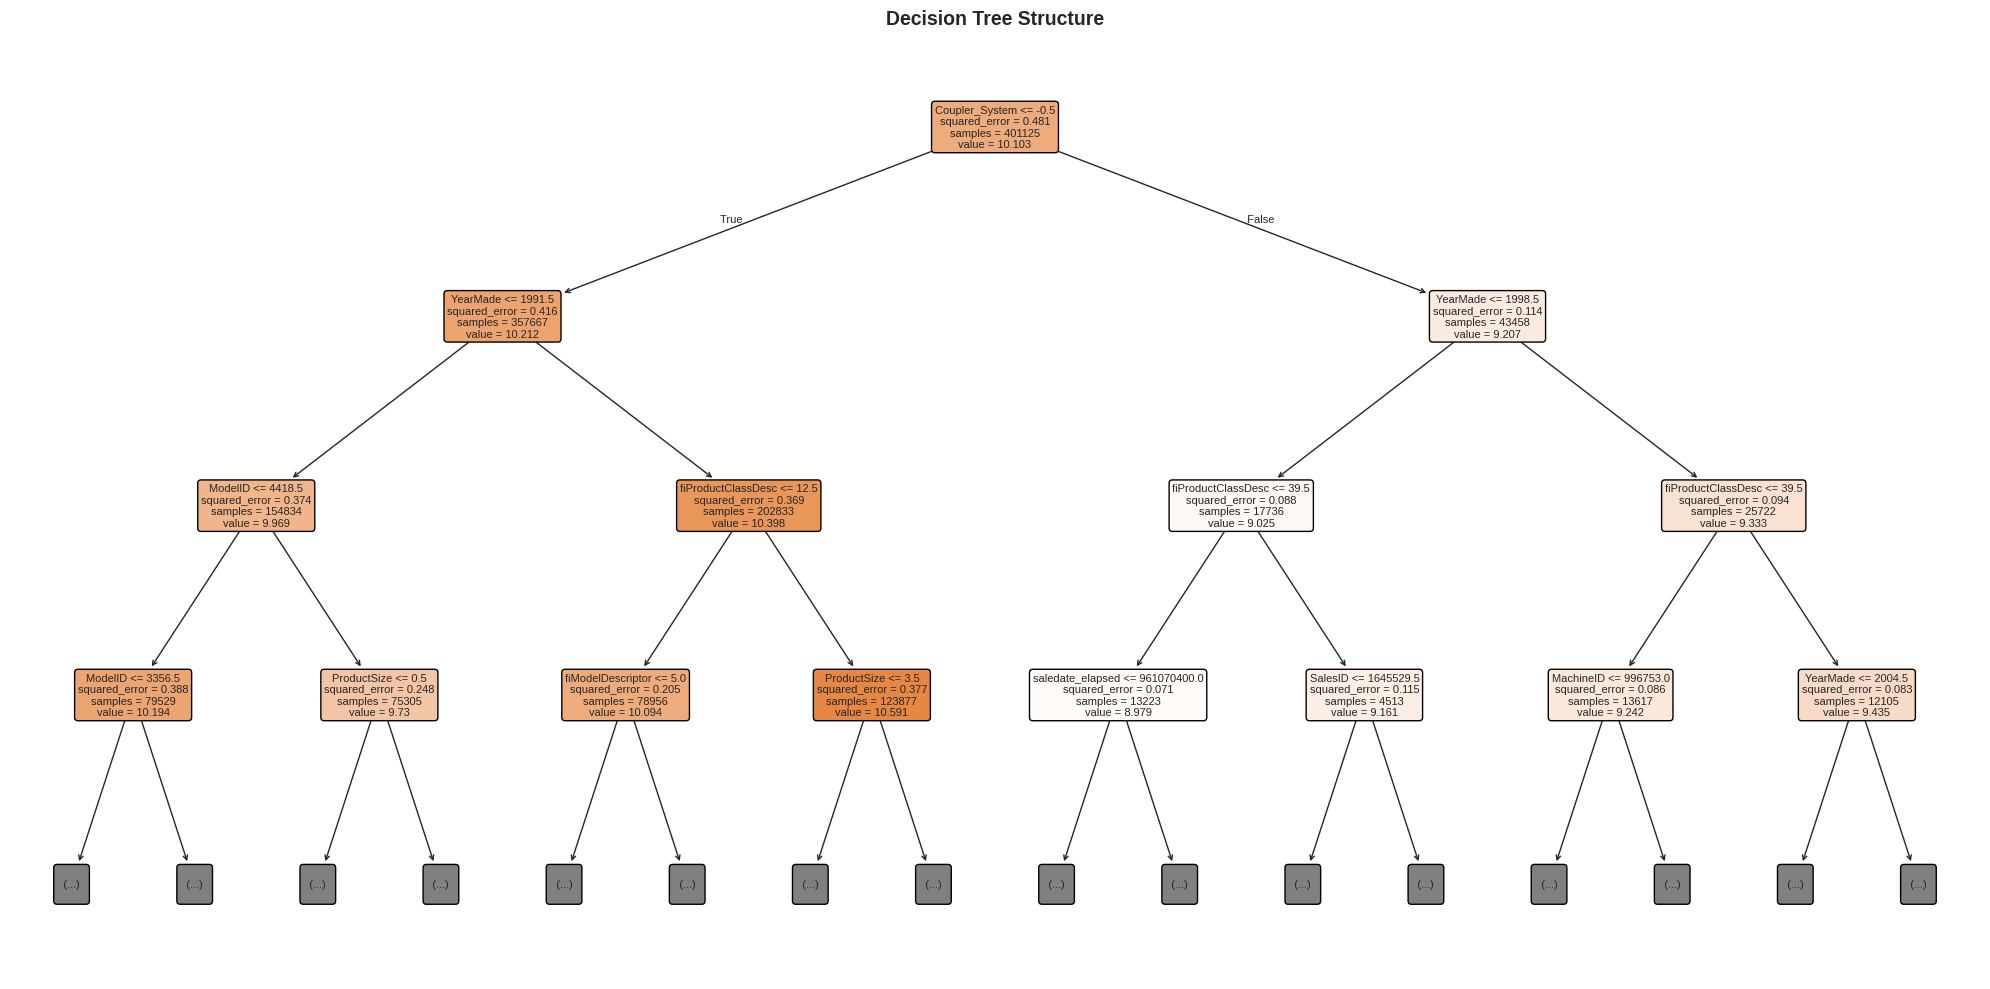

In [28]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    single_tree, 
    feature_names=features_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    max_depth=3  # Show first 3 levels for readability
)
plt.title('Decision Tree Structure', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Reading the tree visualization:**
- **Split condition** (top of each box): e.g., `saleElapsed <= 7152` means "is sale date ≤7152 days from reference?"
- **samples**: number of training examples reaching this node
- **value**: predicted log-price (mean of samples in this node)
- **Color intensity**: darker = higher predicted value

The root split uses `saleElapsed` - confirming that **when** equipment sold strongly affects price (likely due to market trends and depreciation).

### Limitations of a Single Tree

The single tree has fundamental limitations:

1. **Limited capacity**: With max_depth=4, it makes at most 16 distinct predictions regardless of data complexity
2. **Variance**: A different random seed or slightly different data could produce a very different tree
3. **Greedy splits**: Each split is locally optimal, not globally optimal

Increasing depth helps capacity but causes overfitting. Random forests solve this elegantly.

### Random Forest: Ensemble of Trees

A random forest trains many decision trees and averages their predictions. This works because:

1. **Bootstrap sampling**: Each tree trains on a random sample (with replacement) of the data
2. **Feature randomization**: Each split considers only a random subset of features
3. **Averaging**: Individual tree errors tend to cancel out when averaged

The key insight: diverse trees make uncorrelated errors. When errors don't correlate, averaging reduces total error - the statistical foundation of ensemble methods.

In [29]:
from sklearn.ensemble import RandomForestRegressor

random_forest = RandomForestRegressor(
    n_estimators=100,      # 100 trees
    max_features='sqrt',   # Consider sqrt(n_features) at each split
    min_samples_leaf=5,
    n_jobs=-1,             # Use all CPU cores
    random_state=42
)
random_forest.fit(features_train, target_train)

rf_train_predictions = random_forest.predict(features_train)
rf_val_predictions = random_forest.predict(features_validation)

# Store for later comparison
rf_rmse = calculate_rmse(rf_val_predictions, target_validation)

print(f"Random Forest Results:")
print(f"  Training RMSLE:   {calculate_rmse(rf_train_predictions, target_train):.4f}")
print(f"  Validation RMSLE: {rf_rmse:.4f}")
print(f"  Training R²:      {random_forest.score(features_train, target_train):.3f}")
print(f"  Validation R²:    {random_forest.score(features_validation, target_validation):.3f}")

Random Forest Results:
  Training RMSLE:   0.1847
  Validation RMSLE: 0.2624
  Training R²:      0.929
  Validation R²:    0.872


The random forest substantially outperforms the single tree. Key observations:

- **Higher validation R²**: The ensemble captures more of the price variance
- **Lower RMSLE**: Predictions are closer to actual prices
- **No overfitting plateau**: Unlike single trees, adding more trees to a random forest doesn't cause overfitting - predictions just stabilize

This makes random forests an excellent default choice for tabular data: they're hard to mess up.

In [30]:
# Direct comparison
print("Model Comparison:")
print("="*50)
print(f"{'Model':<20} {'Val RMSLE':<12} {'Val R²':<10}")
print("-"*50)
print(f"{'Single Tree':<20} {calculate_rmse(tree_val_predictions, target_validation):<12.4f} {single_tree.score(features_validation, target_validation):<10.3f}")
print(f"{'Random Forest':<20} {calculate_rmse(rf_val_predictions, target_validation):<12.4f} {random_forest.score(features_validation, target_validation):<10.3f}")
print("="*50)

improvement = (calculate_rmse(tree_val_predictions, target_validation) - 
               calculate_rmse(rf_val_predictions, target_validation)) / calculate_rmse(tree_val_predictions, target_validation) * 100
print(f"\nRF reduces RMSLE by {improvement:.1f}% compared to single tree")

Model Comparison:
Model                Val RMSLE    Val R²    
--------------------------------------------------
Single Tree          0.5252       0.489     
Random Forest        0.2624       0.872     

RF reduces RMSLE by 50.0% compared to single tree


### Out-of-Bag (OOB) Error

To understand OOB, we first need to understand **bootstrap sampling**.

When training a random forest with N training samples, each tree doesn't see all N samples. Instead, it draws N samples **with replacement** from the training set. This means:
- Some samples get picked multiple times
- Some samples don't get picked at all

The probability that a specific sample is NOT picked in any single draw is (1 - 1/N). After N draws:

$$P(\text{not picked}) = \left(1 - \frac{1}{N}\right)^N \approx \frac{1}{e} \approx 0.368$$

So roughly **37% of samples are left out** of each tree's training set. These are the "out-of-bag" samples for that tree.

In [31]:
# Demonstrate bootstrap sampling
np.random.seed(42)
n_samples = 10  # Small example
sample_ids = list(range(n_samples))

print("Example: 10 training samples, 3 trees\n")
print("Original samples: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]\n")

for tree_num in range(3):
    # Bootstrap sample (with replacement)
    bootstrap = np.random.choice(sample_ids, size=n_samples, replace=True)
    in_bag = set(bootstrap)
    out_of_bag = set(sample_ids) - in_bag
    
    print(f"Tree {tree_num + 1}:")
    print(f"  Bootstrap sample: {sorted(bootstrap)}")
    print(f"  In-bag (trained on): {sorted(in_bag)}")
    print(f"  Out-of-bag (NOT trained on): {sorted(out_of_bag)}")
    print(f"  OOB fraction: {len(out_of_bag)/n_samples:.0%}\n")

Example: 10 training samples, 3 trees

Original samples: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

Tree 1:
  Bootstrap sample: [np.int64(2), np.int64(3), np.int64(4), np.int64(4), np.int64(6), np.int64(6), np.int64(6), np.int64(7), np.int64(7), np.int64(9)]
  In-bag (trained on): [np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(9)]
  Out-of-bag (NOT trained on): [0, 1, 5, 8]
  OOB fraction: 40%

Tree 2:
  Bootstrap sample: [np.int64(1), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(5), np.int64(7), np.int64(7), np.int64(7)]
  In-bag (trained on): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(7)]
  Out-of-bag (NOT trained on): [0, 6, 8, 9]
  OOB fraction: 40%

Tree 3:
  Bootstrap sample: [np.int64(0), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9), np.int64(9)]
  In-bag (trained on): [np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)

**How OOB prediction works:**

For each training sample, we identify which trees did NOT see it during training. We then:
1. Get predictions from only those trees
2. Average them to get an OOB prediction

This is powerful because each sample is predicted by trees that never trained on it - similar to how a validation set works, but without sacrificing any training data.

```
Sample 0: Not in Tree 1, Tree 3 → OOB prediction = avg(Tree1, Tree3)
Sample 1: Not in Tree 2        → OOB prediction = Tree2's prediction
Sample 2: Not in Tree 1, Tree 2 → OOB prediction = avg(Tree1, Tree2)
...and so on for all training samples
```

The OOB score compares these OOB predictions against actual values.

In [32]:
rf_with_oob = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    min_samples_leaf=5,
    oob_score=True,  # Enable OOB scoring
    n_jobs=-1,
    random_state=42
)
rf_with_oob.fit(features_train, target_train)

print("OOB vs Validation Comparison:")
print("=" * 40)
print(f"OOB R² score:        {rf_with_oob.oob_score_:.4f}")
print(f"Validation R² score: {rf_with_oob.score(features_validation, target_validation):.4f}")
print()
print("The OOB score approximates validation performance.")

OOB vs Validation Comparison:
OOB R² score:        0.8932
Validation R² score: 0.8723

The OOB score approximates validation performance.


**When to use OOB vs validation set:**

| Scenario | Use OOB | Use Validation Set |
|----------|---------|--------------------|
| Limited data | ✓ (no data "wasted") | |
| Quick hyperparameter tuning | ✓ | |
| Time-series / temporal data | | ✓ (captures distribution shift) |
| Need unbiased final estimate | | ✓ |
| Production model evaluation | | ✓ |

For our bulldozer data (temporal), we keep the validation set because OOB samples come from the same time period as training - they don't simulate predicting future sales.

In [33]:
rf_with_oob = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    min_samples_leaf=5,
    oob_score=True,  # Enable OOB scoring
    n_jobs=-1,
    random_state=42
)
rf_with_oob.fit(features_train, target_train)

print(f"OOB R² score:      {rf_with_oob.oob_score_:.4f}")
print(f"Validation R²:     {rf_with_oob.score(features_validation, target_validation):.4f}")
print(f"\nOOB approximates validation performance without a separate holdout set.")
print(f"For temporal data, dedicated validation remains important since OOB")
print(f"doesn't account for time-based distribution shift.")

OOB R² score:      0.8932
Validation R²:     0.8723

OOB approximates validation performance without a separate holdout set.
For temporal data, dedicated validation remains important since OOB
doesn't account for time-based distribution shift.


### Prediction Confidence: When to Trust the Model

A random forest isn't just one model - it's 100 trees, each giving its own prediction. The final prediction is their average. But here's a powerful insight: **how much the trees agree tells us how confident we should be**.

Think of it like asking 100 experts to appraise equipment:
- If 95 experts say "around $45,000" → high confidence
- If experts range from $20,000 to $80,000 → low confidence, even if the average is reasonable

Why would trees disagree? Each tree:
- Trained on a different bootstrap sample (different 63% of data)
- Considered different random feature subsets at each split
- May have learned slightly different patterns

For "typical" examples that resemble the training data, trees tend to agree. For unusual examples or edge cases, trees diverge.

In [34]:
# Get predictions from EACH of the 100 trees (not just the average)
all_tree_predictions = np.array([
    tree.predict(features_validation) 
    for tree in random_forest.estimators_
])

print(f"Shape: {all_tree_predictions.shape}")
print(f"  → 100 trees, each predicting {len(features_validation)} validation samples")

# The random forest's final prediction is the mean across trees
prediction_mean = all_tree_predictions.mean(axis=0)

# The standard deviation tells us how much trees disagree
prediction_std = all_tree_predictions.std(axis=0)

Shape: (100, 11573)
  → 100 trees, each predicting 11573 validation samples


In [35]:
# Let's look at specific examples: one where trees agree, one where they don't

# Find a high-confidence prediction (low std)
confident_idx = np.argmin(prediction_std)
# Find a low-confidence prediction (high std)
uncertain_idx = np.argmax(prediction_std)

print("HIGH CONFIDENCE PREDICTION")
print("=" * 50)
confident_preds = all_tree_predictions[:, confident_idx]
print(f"100 tree predictions (log scale): min={confident_preds.min():.2f}, max={confident_preds.max():.2f}")
print(f"Standard deviation: {prediction_std[confident_idx]:.4f}")
print(f"Final prediction: ${np.exp(prediction_mean[confident_idx]):,.0f}")
print(f"Actual price:     ${np.exp(target_validation.iloc[confident_idx]):,.0f}")

print("\nLOW CONFIDENCE PREDICTION")
print("=" * 50)
uncertain_preds = all_tree_predictions[:, uncertain_idx]
print(f"100 tree predictions (log scale): min={uncertain_preds.min():.2f}, max={uncertain_preds.max():.2f}")
print(f"Standard deviation: {prediction_std[uncertain_idx]:.4f}")
print(f"Final prediction: ${np.exp(prediction_mean[uncertain_idx]):,.0f}")
print(f"Actual price:     ${np.exp(target_validation.iloc[uncertain_idx]):,.0f}")

HIGH CONFIDENCE PREDICTION
100 tree predictions (log scale): min=10.02, max=10.39
Standard deviation: 0.0696
Final prediction: $27,552
Actual price:     $25,000

LOW CONFIDENCE PREDICTION
100 tree predictions (log scale): min=9.37, max=11.64
Standard deviation: 0.6322
Final prediction: $45,016
Actual price:     $115,000


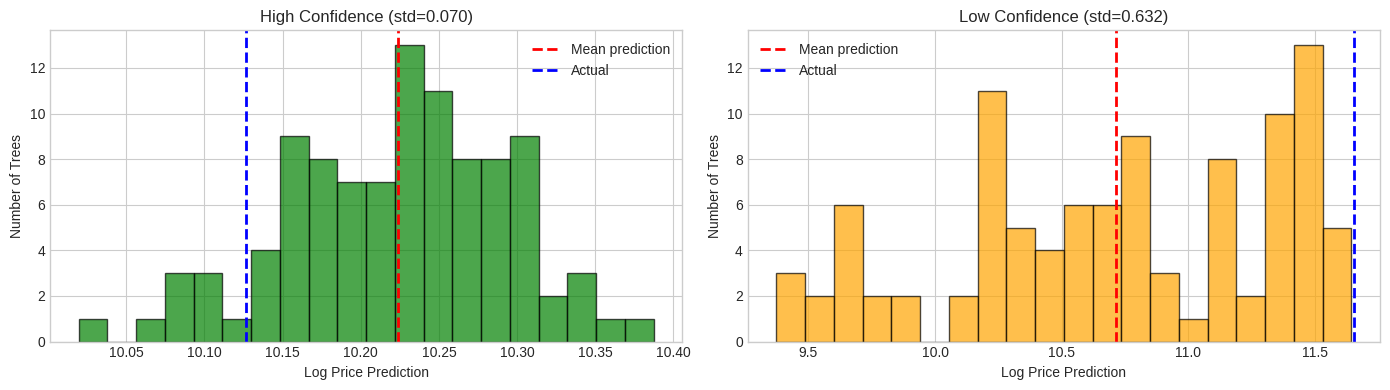

Left: Trees agree closely → we can trust this prediction
Right: Trees spread out → treat this prediction with caution


In [36]:
# Visualize what "tree agreement" looks like
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# High confidence: trees cluster tightly
axes[0].hist(confident_preds, bins=20, edgecolor='black', alpha=0.7, color='green')
axes[0].axvline(prediction_mean[confident_idx], color='red', linestyle='--', linewidth=2, label='Mean prediction')
axes[0].axvline(target_validation.iloc[confident_idx], color='blue', linestyle='--', linewidth=2, label='Actual')
axes[0].set_xlabel('Log Price Prediction')
axes[0].set_ylabel('Number of Trees')
axes[0].set_title(f'High Confidence (std={prediction_std[confident_idx]:.3f})')
axes[0].legend()

# Low confidence: trees spread out
axes[1].hist(uncertain_preds, bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(prediction_mean[uncertain_idx], color='red', linestyle='--', linewidth=2, label='Mean prediction')
axes[1].axvline(target_validation.iloc[uncertain_idx], color='blue', linestyle='--', linewidth=2, label='Actual')
axes[1].set_xlabel('Log Price Prediction')
axes[1].set_ylabel('Number of Trees')
axes[1].set_title(f'Low Confidence (std={prediction_std[uncertain_idx]:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Left: Trees agree closely → we can trust this prediction")
print("Right: Trees spread out → treat this prediction with caution")

**Key question: Does high confidence actually mean better predictions?**

If tree disagreement is meaningful, we'd expect:
- Low disagreement → smaller errors
- High disagreement → larger errors

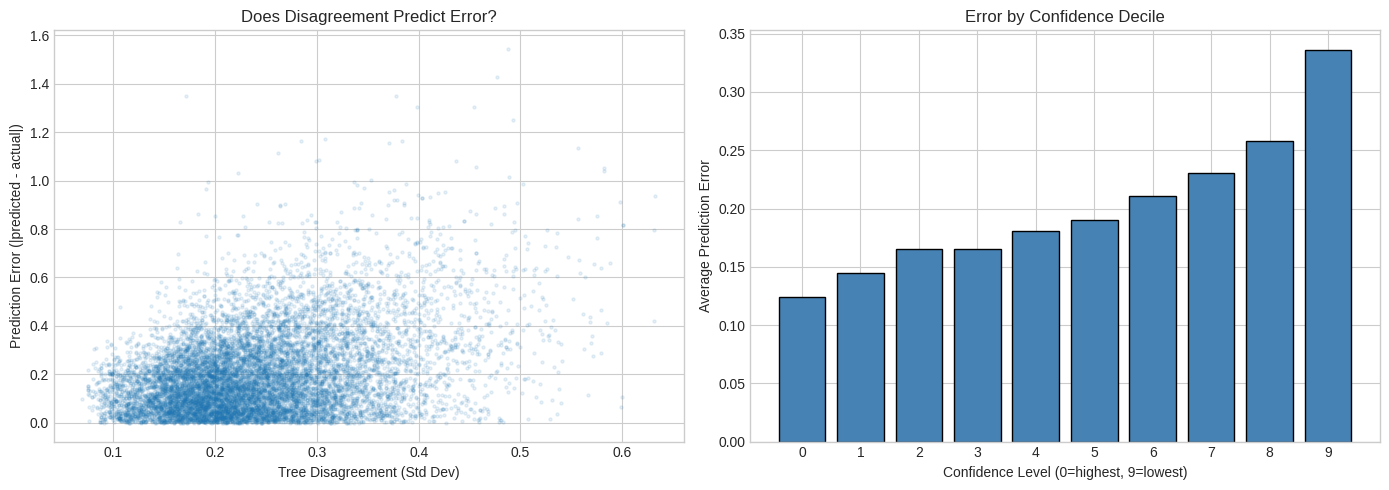

Correlation between disagreement and error: 0.364

The positive correlation confirms: when trees disagree more, predictions are less accurate.


In [37]:
prediction_error = np.abs(prediction_mean - target_validation.values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Scatter plot of std vs error
axes[0].scatter(prediction_std, prediction_error, alpha=0.1, s=5)
axes[0].set_xlabel('Tree Disagreement (Std Dev)')
axes[0].set_ylabel('Prediction Error (|predicted - actual|)')
axes[0].set_title('Does Disagreement Predict Error?')

# Right: Binned analysis - clearer pattern
# Group predictions by confidence level
confidence_bins = pd.qcut(prediction_std, q=10, labels=False)
bin_errors = pd.DataFrame({'bin': confidence_bins, 'error': prediction_error}).groupby('bin')['error'].mean()
bin_stds = pd.DataFrame({'bin': confidence_bins, 'std': prediction_std}).groupby('bin')['std'].mean()

axes[1].bar(range(10), bin_errors.values, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Confidence Level (0=highest, 9=lowest)')
axes[1].set_ylabel('Average Prediction Error')
axes[1].set_title('Error by Confidence Decile')
axes[1].set_xticks(range(10))

plt.tight_layout()
plt.show()

correlation = np.corrcoef(prediction_std, prediction_error)[0, 1]
print(f"Correlation between disagreement and error: {correlation:.3f}")
print(f"\nThe positive correlation confirms: when trees disagree more, predictions are less accurate.")

**Practical applications:**

1. **Confidence intervals**: Report predictions as ranges, not point estimates
   - "Estimated price: $45,000 (±$5,000)" is more honest than just "$45,000"

2. **Flagging uncertain predictions**: In production, route low-confidence predictions to human review

3. **Identifying edge cases**: High uncertainty often indicates unusual examples - equipment combinations the model hasn't seen before

This built-in uncertainty quantification is a major advantage of random forests over single models.

## Feature Importance & Selection

Random forests track how much each feature contributes to predictions. This **feature importance** measures the total reduction in prediction error (variance) achieved by splits on that feature, averaged across all trees.

High importance means: splits on this feature consistently separate high-price from low-price equipment.

This analysis helps us:
1. **Understand the model**: What actually drives equipment prices?
2. **Validate domain knowledge**: Do important features match expert intuition?
3. **Simplify the model**: Can we drop unimportant features without losing accuracy?

In [38]:
def get_feature_importance(model, feature_names):
    """Extract and sort feature importances."""
    return pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

feature_importance = get_feature_importance(random_forest, features_train.columns)

print("Top 15 Features by Importance:")
print("=" * 40)
for idx, row in feature_importance.head(15).iterrows():
    bar = '█' * int(row['importance'] * 50)
    print(f"{row['feature']:<25} {row['importance']:.3f} {bar}")

Top 15 Features by Importance:
YearMade                  0.126 ██████
ProductSize               0.073 ███
fiSecondaryDesc           0.061 ███
fiProductClassDesc        0.056 ██
ModelID                   0.055 ██
Grouser_Tracks            0.049 ██
Hydraulics_Flow           0.048 ██
fiModelDesc               0.047 ██
Enclosure                 0.045 ██
fiBaseModel               0.036 █
Coupler_System            0.035 █
fiModelDescriptor         0.033 █
SalesID                   0.031 █
saledate_elapsed          0.030 █
ProductGroupDesc          0.029 █


**Interpreting the top features:**

The most important features for predicting bulldozer prices are:

- **Time-related features** (`saleElapsed`, `YearMade`, `saleYear`): When the equipment was made and sold matters enormously. Newer equipment and recent sales command higher prices. The depreciation curve is a major price driver.

- **Product identifiers** (`ProductSize`, `fiProductClassDesc`, `fiModelDesc`): What type of equipment it is - a large track excavator vs a small wheel loader have very different price ranges.

- **Equipment characteristics** (`Enclosure`, `Hydraulics`): Specific features that affect utility and value.

This matches domain intuition: age, equipment type, and features drive heavy equipment prices.

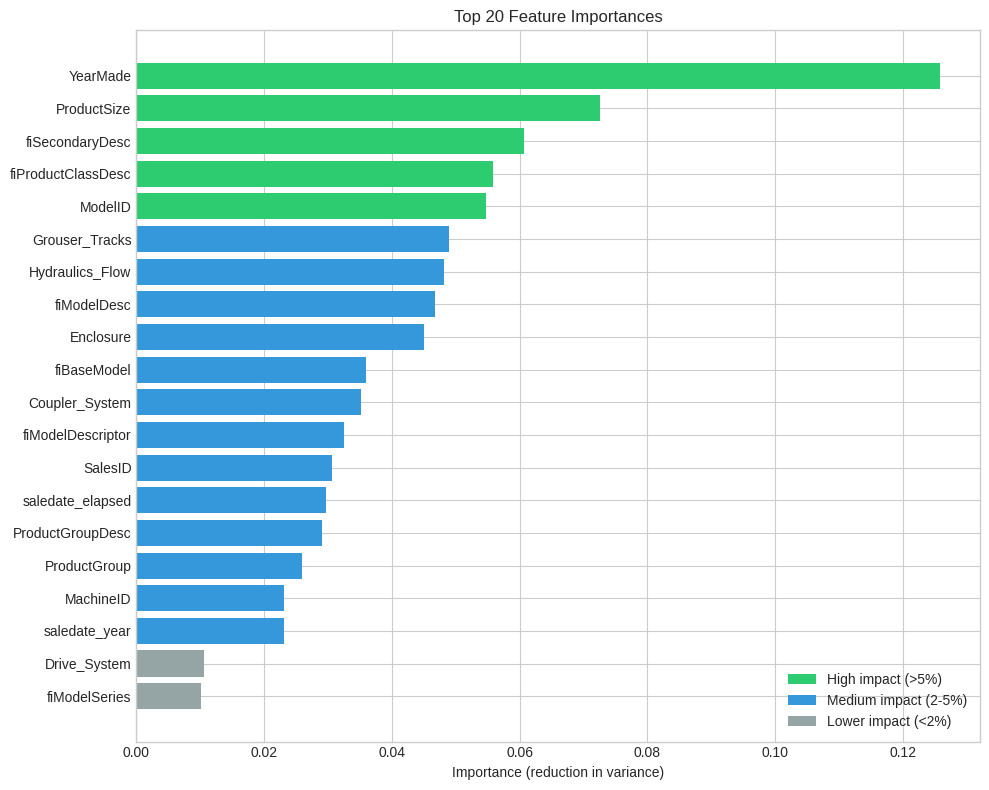

In [39]:
fig, ax = plt.subplots(figsize=(10, 8))
top_20 = feature_importance.head(20)

colors = ['#2ecc71' if imp > 0.05 else '#3498db' if imp > 0.02 else '#95a5a6' 
          for imp in top_20['importance']]

ax.barh(range(len(top_20)), top_20['importance'].values, color=colors)
ax.set_yticks(range(len(top_20)))
ax.set_yticklabels(top_20['feature'].values)
ax.set_xlabel('Importance (reduction in variance)')
ax.set_title('Top 20 Feature Importances')
ax.invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='High impact (>5%)'),
    Patch(facecolor='#3498db', label='Medium impact (2-5%)'),
    Patch(facecolor='#95a5a6', label='Lower impact (<2%)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

**The long tail of features**

Notice how a handful of features dominate while many others contribute very little. This is typical - most predictive power comes from a few key variables.

The question: how many features do we actually need?

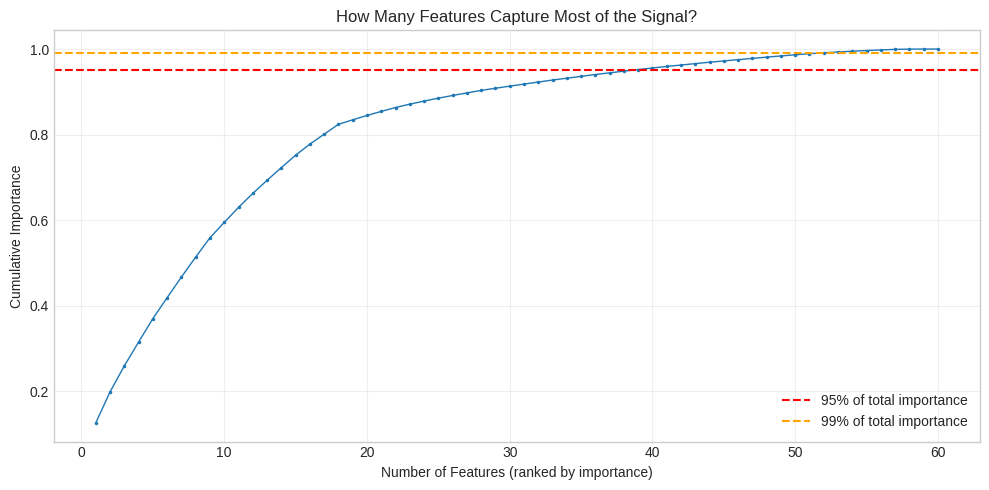

Features for 95% importance: 39 (out of 60)
Features for 99% importance: 52

The remaining 8 features contribute <1% combined.


In [40]:
cumulative_importance = feature_importance['importance'].cumsum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumulative_importance) + 1), cumulative_importance, 
        marker='.', markersize=3, linewidth=1)
ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='95% of total importance')
ax.axhline(y=0.99, color='orange', linestyle='--', linewidth=1.5, label='99% of total importance')

ax.set_xlabel('Number of Features (ranked by importance)')
ax.set_ylabel('Cumulative Importance')
ax.set_title('How Many Features Capture Most of the Signal?')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

features_for_95 = (cumulative_importance < 0.95).sum() + 1
features_for_99 = (cumulative_importance < 0.99).sum() + 1
print(f"Features for 95% importance: {features_for_95} (out of {len(feature_importance)})")
print(f"Features for 99% importance: {features_for_99}")
print(f"\nThe remaining {len(feature_importance) - features_for_99} features contribute <1% combined.")

### Redundant Features

Some features capture the same underlying information:
- `saleYear` and `saleElapsed` both measure when the sale happened
- `YearMade` and equipment age are mathematically related
- Multiple product ID fields may encode similar categorical information

When features are redundant:
- Importance gets **split** between them (each looks less important than it really is)
- Removing one may not hurt the model since the other carries the same signal

A **dendrogram** visualizes which features cluster together based on correlation:

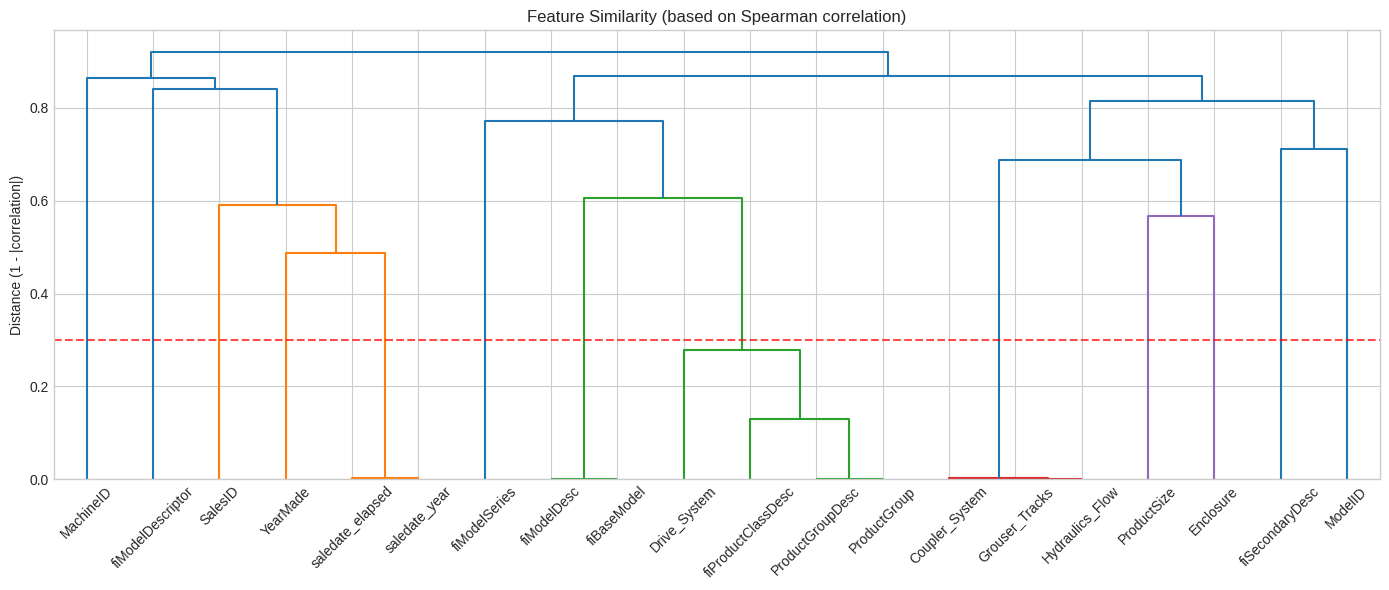

In [41]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# Analyze top 20 features
top_features = feature_importance.head(20)['feature'].tolist()
feature_subset = features_train[top_features]

# Spearman correlation (rank-based, handles non-linear relationships)
corr_matrix = feature_subset.corr(method='spearman')

# Convert correlation to distance: high correlation = low distance
corr_distance = 1 - np.abs(corr_matrix)
linkage = hierarchy.linkage(squareform(corr_distance), method='average')

fig, ax = plt.subplots(figsize=(14, 6))
hierarchy.dendrogram(linkage, labels=top_features, leaf_rotation=45, leaf_font_size=10, ax=ax)
ax.set_title('Feature Similarity (based on Spearman correlation)')
ax.set_ylabel('Distance (1 - |correlation|)')
ax.axhline(y=0.3, color='red', linestyle='--', alpha=0.7, label='High correlation threshold')

plt.tight_layout()
plt.show()

**Reading the dendrogram:**

- **Height** = distance = 1 - |correlation|
- Features joining at **low height** (near bottom) are highly correlated
- Features joining at **high height** (near top) are independent

Look for tight clusters below the red line - those features likely carry redundant information. From each cluster, you could keep just one representative.

For example, if `saleYear`, `saleElapsed`, and `saleMonth` cluster together, they all capture "when was this sold" - keeping one might suffice.

In [42]:
# Does removing low-importance features hurt performance?
print("Testing model performance with fewer features:\n")

results = []
for n_features in [10, 20, 30, 50, len(features_train.columns)]:
    if n_features > len(features_train.columns):
        continue
    
    top_n = feature_importance.head(n_features)['feature'].tolist()
    
    rf_test = RandomForestRegressor(
        n_estimators=100, max_features='sqrt', min_samples_leaf=5,
        n_jobs=-1, random_state=42
    )
    rf_test.fit(features_train[top_n], target_train)
    preds = rf_test.predict(features_validation[top_n])
    rmse = calculate_rmse(preds, target_validation)
    results.append((n_features, rmse))
    
    label = f"All {n_features}" if n_features == len(features_train.columns) else f"Top {n_features}"
    print(f"{label:<12} features → RMSLE: {rmse:.4f}")

# Store reduced features result for later comparison
reduced_rmse = results[2][1]  # Top 30 features result

print("\n" + "="*50)
best_n, best_rmse = min(results, key=lambda x: x[1])
print(f"Best: {best_n} features with RMSLE {best_rmse:.4f}")
print(f"Using top 30 features is {'better' if reduced_rmse <= results[-1][1] else 'slightly worse'} than all {len(features_train.columns)}")

Testing model performance with fewer features:

Top 10       features → RMSLE: 0.2831
Top 20       features → RMSLE: 0.2459
Top 30       features → RMSLE: 0.2485
Top 50       features → RMSLE: 0.2545
All 60       features → RMSLE: 0.2615

Best: 20 features with RMSLE 0.2459
Using top 30 features is better than all 60


**Key finding**: We can drop most features with minimal impact on accuracy.

This happens because:
1. Low-importance features add noise without signal
2. Redundant features don't provide new information
3. Random forests are robust to irrelevant features, but simpler is still better

**Practical implication**: In production, using fewer features means:
- Faster training and inference
- Simpler data pipelines (fewer features to collect/validate)
- Easier model maintenance

Random forests build trees independently and average them. An alternative ensemble strategy: **gradient boosting** - where each tree learns from the mistakes of previous trees.

## Gradient Boosting: Learning from Mistakes

**Random Forest:** Build 100 trees independently, average their predictions.

**Gradient Boosting:** Build trees one at a time. Each new tree focuses on fixing the errors of all previous trees combined.

Think of it like this:
- **Tree 1:** "I'll predict the price" → Gets some right, some wrong
- **Tree 2:** "I'll predict how wrong Tree 1 was" → Corrects some errors
- **Tree 3:** "I'll predict how wrong Trees 1+2 combined were" → Corrects remaining errors
- ...and so on

  1. Initial prediction = mean of actuals ✓                                                                     
  2. Residuals = actuals - prediction ✓                                                                         
  3. Build regression tree with residuals as target, leaves output average residual of samples in that leaf ✓   
  4. new_prediction = old_prediction + (tree_output × lr), then new_residual = actual - new_prediction ✓        
  5. Build next tree on the new residuals, repeat ✓


If you didn't get that - don't worry, the easiest way is to watch a video on it and try to get intuition for it.
What matters here is that we're using independent trees that are stacked on top of each other. So one tree affects the next one. 
We're also using a learning rate which affects how fast the tree is reducing the errors, which is meant to reduce overfitting

In [43]:
# Simple example: 10 equipment sales
# We'll manually build a gradient boosting model step by step

np.random.seed(42)
n_samples = 10
sample_idx = np.random.choice(len(features_train), n_samples, replace=False)

X_simple = features_train.iloc[sample_idx]
y_simple = target_train.iloc[sample_idx].values

# Format for display
print("Our 10 equipment sales (log prices):")
print("=" * 40)
for i, price in enumerate(y_simple):
    print(f"Equipment {i+1}: {price:.2f} (${np.exp(price):,.0f})")


Our 10 equipment sales (log prices):
Equipment 1: 10.46 ($35,000)
Equipment 2: 10.20 ($27,000)
Equipment 3: 11.10 ($66,000)
Equipment 4: 10.67 ($43,000)
Equipment 5: 11.43 ($92,000)
Equipment 6: 9.51 ($13,500)
Equipment 7: 9.90 ($20,000)
Equipment 8: 9.85 ($19,000)
Equipment 9: 10.02 ($22,500)
Equipment 10: 9.39 ($12,000)


In [44]:
# STEP 1: First tree predicts the target directly
tree1 = DecisionTreeRegressor(max_depth=2, random_state=1)
tree1.fit(X_simple, y_simple)
pred1 = tree1.predict(X_simple)

# Calculate errors (residuals)
residuals1 = y_simple - pred1

print("STEP 1: Tree 1 predicts prices directly")
print("=" * 60)
print(f"{'Equipment':<12} {'Actual':<10} {'Tree1 Pred':<12} {'Error':<10}")
print("-" * 60)
for i in range(n_samples):
    print(f"{i+1:<12} {y_simple[i]:<10.2f} {pred1[i]:<12.2f} {residuals1[i]:>+.2f}")
print("=" * 60)
print(f"Mean Squared Error: {np.mean(residuals1**2):.4f}")

STEP 1: Tree 1 predicts prices directly
Equipment    Actual     Tree1 Pred   Error     
------------------------------------------------------------
1            10.46      10.19        +0.28
2            10.20      10.19        +0.02
3            11.10      11.10        +0.00
4            10.67      10.19        +0.48
5            11.43      11.43        +0.00
6            9.51       9.45         +0.06
7            9.90       10.19        -0.28
8            9.85       10.19        -0.33
9            10.02      10.19        -0.16
10           9.39       9.45         -0.06
Mean Squared Error: 0.0536


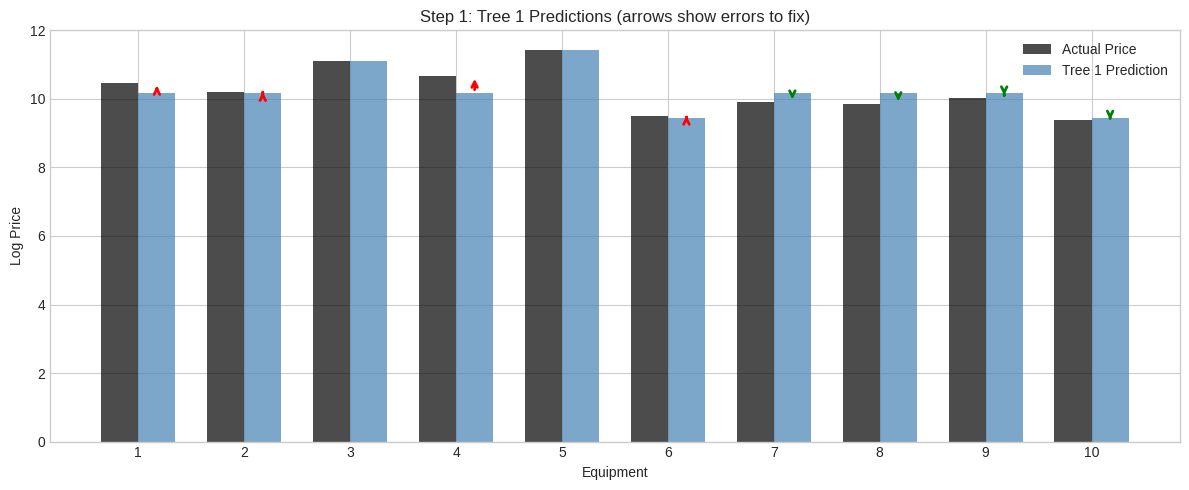

Red arrows: Tree 1 predicted too LOW (needs to increase)
Green arrows: Tree 1 predicted too HIGH (needs to decrease)


In [45]:
# Visualize: Tree 1's predictions vs actual
fig, ax = plt.subplots(figsize=(12, 5))

x_pos = np.arange(n_samples)
width = 0.35

# Actual values
ax.bar(x_pos - width/2, y_simple, width, label='Actual Price', color='black', alpha=0.7)
# Tree 1 predictions
ax.bar(x_pos + width/2, pred1, width, label='Tree 1 Prediction', color='steelblue', alpha=0.7)

# Draw error arrows
for i in range(n_samples):
    color = 'red' if residuals1[i] > 0 else 'green'
    ax.annotate('', xy=(i + width/2, y_simple[i]), xytext=(i + width/2, pred1[i]),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))

ax.set_xlabel('Equipment')
ax.set_ylabel('Log Price')
ax.set_title('Step 1: Tree 1 Predictions (arrows show errors to fix)')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'{i+1}' for i in range(n_samples)])
ax.legend()
plt.tight_layout()
plt.show()

print("Red arrows: Tree 1 predicted too LOW (needs to increase)")
print("Green arrows: Tree 1 predicted too HIGH (needs to decrease)")

In [46]:
# STEP 2: Tree 2 learns to predict the ERRORS (not the prices!)
tree2 = DecisionTreeRegressor(max_depth=2, random_state=2)
tree2.fit(X_simple, residuals1)  # <-- Note: fitting on RESIDUALS
pred2 = tree2.predict(X_simple)

# Learning rate: don't fully trust Tree 2's corrections
learning_rate = 0.5

# Combined prediction: Tree1 + learning_rate * Tree2
combined_pred = pred1 + learning_rate * pred2
residuals2 = y_simple - combined_pred

print("STEP 2: Tree 2 predicts the ERRORS from Step 1")
print("=" * 70)
print(f"{'Equipment':<10} {'Error to fix':<14} {'Tree2 pred':<12} {'Correction':<12} {'New Error':<10}")
print("-" * 70)
for i in range(n_samples):
    correction = learning_rate * pred2[i]
    print(f"{i+1:<10} {residuals1[i]:>+.2f}{'':8} {pred2[i]:>+.2f}{'':6} {correction:>+.2f}{'':6} {residuals2[i]:>+.2f}")
print("=" * 70)
print(f"MSE reduced: {np.mean(residuals1**2):.4f} → {np.mean(residuals2**2):.4f}")

STEP 2: Tree 2 predicts the ERRORS from Step 1
Equipment  Error to fix   Tree2 pred   Correction   New Error 
----------------------------------------------------------------------
1          +0.28         +0.02       +0.01       +0.27
2          +0.02         +0.02       +0.01       +0.01
3          +0.00         +0.02       +0.01       -0.01
4          +0.48         +0.48       +0.24       +0.24
5          +0.00         +0.02       +0.01       -0.01
6          +0.06         +0.02       +0.01       +0.05
7          -0.28         -0.31       -0.15       -0.13
8          -0.33         -0.31       -0.15       -0.18
9          -0.16         +0.02       +0.01       -0.17
10         -0.06         +0.02       +0.01       -0.07
MSE reduced: 0.0536 → 0.0217


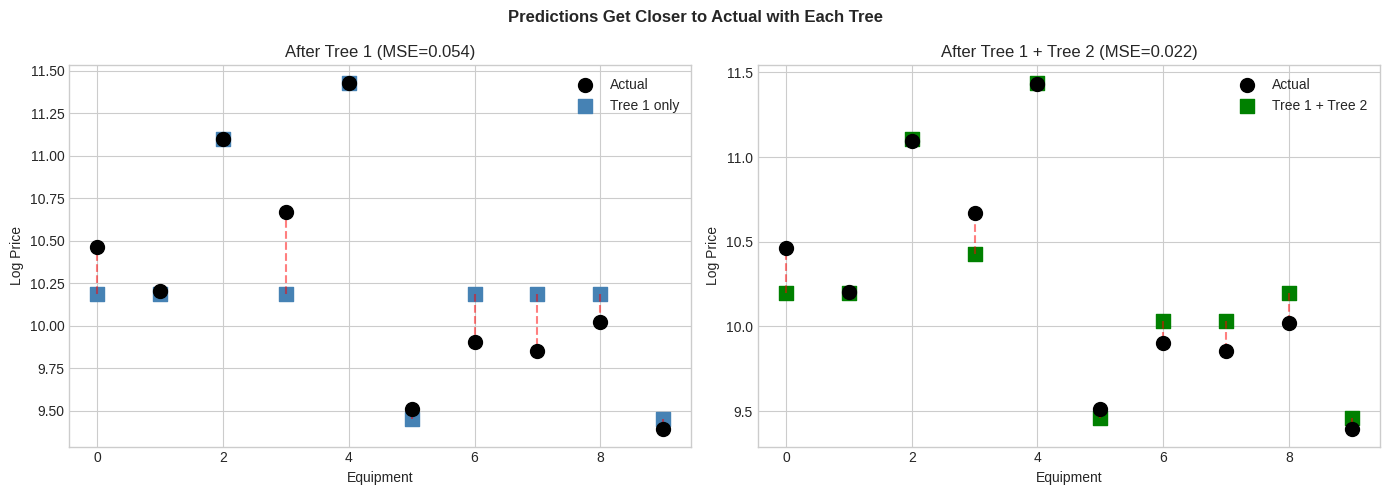

In [47]:
# Visualize the improvement
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_pos = np.arange(n_samples)

# Left: After Tree 1 only
axes[0].scatter(x_pos, y_simple, c='black', s=100, label='Actual', zorder=5)
axes[0].scatter(x_pos, pred1, c='steelblue', s=100, marker='s', label='Tree 1 only')
for i in range(n_samples):
    axes[0].plot([i, i], [pred1[i], y_simple[i]], 'r--', alpha=0.5)
axes[0].set_xlabel('Equipment')
axes[0].set_ylabel('Log Price')
axes[0].set_title(f'After Tree 1 (MSE={np.mean(residuals1**2):.3f})')
axes[0].legend()

# Right: After Tree 1 + Tree 2
axes[1].scatter(x_pos, y_simple, c='black', s=100, label='Actual', zorder=5)
axes[1].scatter(x_pos, combined_pred, c='green', s=100, marker='s', label='Tree 1 + Tree 2')
for i in range(n_samples):
    axes[1].plot([i, i], [combined_pred[i], y_simple[i]], 'r--', alpha=0.5)
axes[1].set_xlabel('Equipment')
axes[1].set_ylabel('Log Price')
axes[1].set_title(f'After Tree 1 + Tree 2 (MSE={np.mean(residuals2**2):.3f})')
axes[1].legend()

plt.suptitle('Predictions Get Closer to Actual with Each Tree', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [48]:
# Continue for a few more rounds to see the pattern
print("Continuing the boosting process...")
print("=" * 50)

# Reset and track full history
predictions = np.zeros(n_samples)
mse_history = [np.mean((y_simple - predictions)**2)]
trees = []

for round_num in range(1, 8):
    residuals = y_simple - predictions
    
    tree = DecisionTreeRegressor(max_depth=2, random_state=round_num)
    tree.fit(X_simple, residuals)
    trees.append(tree)
    
    predictions += learning_rate * tree.predict(X_simple)
    mse = np.mean((y_simple - predictions)**2)
    mse_history.append(mse)
    
    print(f"Round {round_num}: MSE = {mse:.4f}")

print("=" * 50)
print(f"\nMSE reduced from {mse_history[0]:.4f} to {mse_history[-1]:.4f}")
print(f"That's a {(1 - mse_history[-1]/mse_history[0])*100:.0f}% reduction in error!")

Continuing the boosting process...
Round 1: MSE = 26.4263
Round 2: MSE = 6.6120
Round 3: MSE = 1.6563
Round 4: MSE = 0.4146
Round 5: MSE = 0.1038
Round 6: MSE = 0.0261
Round 7: MSE = 0.0065

MSE reduced from 105.5445 to 0.0065
That's a 100% reduction in error!


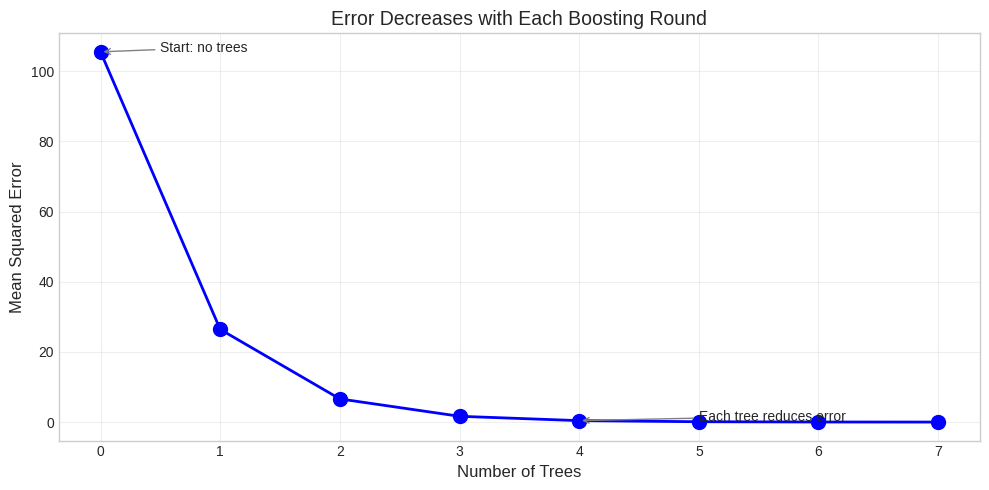

In [49]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(range(len(mse_history)), mse_history, 'bo-', linewidth=2, markersize=10)
ax.set_xlabel('Number of Trees', fontsize=12)
ax.set_ylabel('Mean Squared Error', fontsize=12)
ax.set_title('Error Decreases with Each Boosting Round', fontsize=14)
ax.set_xticks(range(len(mse_history)))
ax.grid(True, alpha=0.3)

# Annotate
ax.annotate('Start: no trees', xy=(0, mse_history[0]), xytext=(0.5, mse_history[0]+0.02),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))
ax.annotate('Each tree reduces error', xy=(4, mse_history[4]), xytext=(5, mse_history[4]+0.03),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='gray'))

plt.tight_layout()
plt.show()

### The Gradient Boosting Recipe

```
1. Start with prediction = 0
2. For each round:
   a. Calculate errors: residuals = actual - current_prediction
   b. Train a tree to predict these residuals
   c. Update: prediction += learning_rate × tree_prediction
3. Final prediction = sum of all tree contributions
```

**Why the learning rate?**
- Without it (learning_rate=1): Each tree fully corrects errors → risk of overfitting
- With it (e.g., 0.1): Each tree makes small corrections → more robust, needs more trees

**Key difference from Random Forest:**

| | Random Forest | Gradient Boosting |
|---|---------------|-------------------|
| Training | Trees built independently | Trees built sequentially |
| Each tree predicts | The target (price) | The residuals (errors) |
| Combining | Average all trees | Sum with learning rate |
| Risk | Hard to overfit | Can overfit → use early stopping |

### XGBoost: The Industry Workhorse

XGBoost dominated Kaggle competitions for years and remains extremely popular in industry. It's not always the fastest or newest, but it's battle-tested, well-documented, and predictable.

Let me share what I consider the most important things to know when working with XGBoost (and gradient boosting in general).

**The #1 Rule: Always Use Early Stopping**

This is probably the single most important piece of advice for gradient boosting. Unlike Random Forests (where more trees rarely hurt), gradient boosting can and will overfit if you add too many trees.

The old way: guess `n_estimators=100` or `n_estimators=500` and hope for the best.

The right way: set `n_estimators=10000` and let the model figure out when to stop by monitoring validation performance.

I've seen so many beginners skip early stopping and wonder why their model overfits. Don't be that person.

In [50]:
import xgboost as xgb

# The right way to train XGBoost: early stopping from the start
xgb_model = xgb.XGBRegressor(
    # n_estimators: maximum number of trees to build
    # Set this high - early stopping will find the optimal number
    # Think of it as "I'm willing to build up to 2000 trees if needed"
    n_estimators=2000,
    
    # learning_rate: how much each tree's prediction counts
    # Default is 0.3 (aggressive). I prefer 0.05 (conservative, more precise)
    # Lower values = each tree contributes less = need more trees = better results usually
    learning_rate=0.05,
    
    # early_stopping_rounds: patience before stopping
    # "Stop training if validation score doesn't improve for 50 consecutive trees"
    # This prevents overfitting automatically
    early_stopping_rounds=50,
    
    random_state=42,  # For reproducibility
    n_jobs=-1         # Use all CPU cores for parallel training
)

Now we train the model. The `.fit()` method is where the actual learning happens - XGBoost will build trees one by one, each trying to correct the errors of the previous ones.

The key here is `eval_set`: we give XGBoost our validation data so it can monitor how well it's doing on data it hasn't trained on. After each tree is built, XGBoost checks: "Did my validation score improve?" If it hasn't improved for 50 trees in a row, it stops - that's early stopping in action.

In [51]:
# .fit() - This is where the magic happens
# XGBoost will:
#   1. Build tree #1 to predict log_price
#   2. Calculate residuals (errors) on training data
#   3. Build tree #2 to predict those residuals
#   4. Update predictions, calculate new residuals
#   5. Repeat until early stopping kicks in

xgb_model.fit(
    # Training data: what the model learns from
    features_train,   # X: the input features (equipment age, type, usage hours, etc.)
    target_train,     # y: what we're trying to predict (log sale price)
    
    # eval_set: validation data for early stopping to monitor
    # Format is a list of tuples: [(X_val, y_val)]
    # You can pass multiple validation sets, but one is usually enough
    # The model DOES NOT train on this data - it only uses it to check performance
    eval_set=[(features_validation, target_validation)],
    
    # verbose: controls how much output you see during training
    # False = silent, True = print every tree, int = print every N trees
    verbose=False
)

# At this point, the model is trained. Let's see how many trees it actually used:
print(f"Training complete!")
print(f"Trees built: {xgb_model.best_iteration} (out of 2000 maximum)")
print(f"Training stopped because validation score didn't improve for 50 rounds.")

Training complete!
Trees built: 1745 (out of 2000 maximum)
Training stopped because validation score didn't improve for 50 rounds.


Now we use the trained model to make predictions on data it hasn't seen. This is the moment of truth - how well does our model generalize?

In [52]:
# .predict() - Use the trained model to make predictions
# For each row in features_validation, the model:
#   1. Passes it through tree #1, gets a prediction
#   2. Passes it through tree #2, gets a correction
#   3. ... continues through all trees
#   4. Sums up: initial_pred + (lr * tree1) + (lr * tree2) + ...

xgb_predictions = xgb_model.predict(features_validation)

# Let's look at what we got
print("Sample predictions (first 5 equipment sales):")
print("=" * 50)
for i in range(5):
    predicted_log_price = xgb_predictions[i]
    actual_log_price = target_validation.iloc[i]
    
    # Convert back to actual dollars for interpretability
    predicted_price = np.exp(predicted_log_price)
    actual_price = np.exp(actual_log_price)
    
    print(f"Equipment {i+1}:")
    print(f"  Predicted: ${predicted_price:>10,.0f} (log: {predicted_log_price:.3f})")
    print(f"  Actual:    ${actual_price:>10,.0f} (log: {actual_log_price:.3f})")
    print()

Sample predictions (first 5 equipment sales):
Equipment 1:
  Predicted: $    46,662 (log: 10.751)
  Actual:    $    31,000 (log: 10.342)

Equipment 2:
  Predicted: $    59,735 (log: 10.998)
  Actual:    $    54,000 (log: 10.897)

Equipment 3:
  Predicted: $    35,745 (log: 10.484)
  Actual:    $    26,500 (log: 10.185)

Equipment 4:
  Predicted: $    17,120 (log: 9.748)
  Actual:    $    10,000 (log: 9.210)

Equipment 5:
  Predicted: $    42,978 (log: 10.668)
  Actual:    $    35,000 (log: 10.463)



Finally, we calculate RMSE (Root Mean Squared Error) on our log-transformed prices. Since we're working with log prices, this is equivalent to RMSLE (Root Mean Squared Log Error) on the original prices - a metric that cares about relative errors, not absolute dollar amounts.

In [53]:
# Calculate RMSE: how far off are our predictions on average?
# Formula: sqrt(mean((predicted - actual)^2))
# Lower is better. Perfect predictions would give RMSE = 0

xgb_rmse = calculate_rmse(xgb_predictions, target_validation)

print(f"XGBoost Results:")
print(f"  RMSLE: {xgb_rmse:.4f}")
print(f"\nWhat does this number mean?")
print(f"  - RMSLE of ~0.23 means predictions are off by roughly 23% on average")
print(f"  - For a $100k machine, we'd typically be within ±$23k")
print(f"  - For a $500k machine, we'd typically be within ±$115k")
print(f"  (This is approximate - RMSLE penalizes under-predictions more)")

XGBoost Results:
  RMSLE: 0.2352

What does this number mean?
  - RMSLE of ~0.23 means predictions are off by roughly 23% on average
  - For a $100k machine, we'd typically be within ±$23k
  - For a $500k machine, we'd typically be within ±$115k
  (This is approximate - RMSLE penalizes under-predictions more)


**Learning Rate: My Personal Take**

The default learning rate in XGBoost is 0.3. I almost never use it. Here's my mental model:

- `learning_rate=0.3`: Fast training, but each tree makes big corrections. Like taking huge steps when walking - you might overshoot.
- `learning_rate=0.05-0.1`: My usual starting point. Good balance between speed and precision.
- `learning_rate=0.01`: When I really want to squeeze out performance and don't mind waiting. Each tree whispers its correction instead of shouting.

**The tradeoff is simple:** Lower learning rate = need more trees = longer training. But with early stopping, you don't have to think about this - just set it low and let early stopping decide how many trees you need.

Let's see this in action:

In [54]:
import time

# Comparing learning rates WITH early stopping
# This shows the tradeoff: lower learning rate = more trees = often better results
# BUT: more trees = slower inference in production

print("Learning rate comparison (with early stopping):")
print("=" * 75)
print(f"{'LR':<6} {'RMSLE':<10} {'Trees':<8} {'Inference Time':<18} {'Note'}")
print("-" * 75)

learning_rate_results = []

for learning_rate in [0.3, 0.1, 0.05, 0.01]:
    model = xgb.XGBRegressor(
        n_estimators=3000,
        learning_rate=learning_rate,
        early_stopping_rounds=50,
        random_state=42,
        n_jobs=-1
    )
    
    model.fit(
        features_train, target_train,
        eval_set=[(features_validation, target_validation)],
        verbose=False
    )
    
    # Measure inference time (run multiple times for stability)
    inference_times = []
    for _ in range(5):
        start_time = time.time()
        predictions = model.predict(features_validation)
        inference_times.append(time.time() - start_time)
    avg_inference_time = np.mean(inference_times)
    
    rmse = calculate_rmse(predictions, target_validation)
    trees_used = model.best_iteration
    
    learning_rate_results.append({
        'learning_rate': learning_rate, 
        'rmse': rmse, 
        'trees': trees_used,
        'inference_ms': avg_inference_time * 1000
    })
    
    print(f"{learning_rate:<6} {rmse:<10.4f} {trees_used:<8} {avg_inference_time*1000:>6.1f} ms")

print("=" * 75)
print("\nThe tradeoff:")
print("  - Lower learning rate → more trees → better accuracy → slower inference")
print("  - In production, you might accept slightly worse accuracy for 5x faster predictions")
print("  - For batch processing (not real-time), use lower learning rate")
print("  - For real-time serving with latency constraints, consider higher learning rate")

Learning rate comparison (with early stopping):
LR     RMSLE      Trees    Inference Time     Note
---------------------------------------------------------------------------
0.3    0.2422     272         7.7 ms
0.1    0.2369     791        19.2 ms
0.05   0.2352     1745       40.3 ms
0.01   0.2484     2999       44.7 ms

The tradeoff:
  - Lower learning rate → more trees → better accuracy → slower inference
  - In production, you might accept slightly worse accuracy for 5x faster predictions
  - For batch processing (not real-time), use lower learning rate
  - For real-time serving with latency constraints, consider higher learning rate


**Common Pitfalls I See All The Time**

1. **Not using early stopping.** I've said it before, I'll say it again. Set `n_estimators` high and let early stopping find the right number. Guessing leads to either underfitting or overfitting.

2. **Using the default learning rate.** The default 0.3 is aggressive. Start with 0.05-0.1 for better results.

3. **Tuning too many hyperparameters.** Start with learning_rate + max_depth + early stopping. That gets you 90% of the way. The other params are for squeezing out the last few percent.

4. **Ignoring feature engineering.** A simple model with great features beats a tuned model with bad features. Spend your time there first.

5. **For time-based data: using random train/test splits.** If you're predicting the future, your validation should mimic that. Split by time, not randomly.

### LightGBM: When Speed Matters

Microsoft's LightGBM is my go-to for quick experimentation. It's typically 2-10x faster than XGBoost on larger datasets, uses less memory, and often performs just as well.

The main technical difference: XGBoost grows trees **level-by-level** (all nodes at depth 1, then all at depth 2, etc.). LightGBM grows **leaf-by-leaf** (always splitting the leaf with the highest potential gain). This is more efficient but can overfit more easily on small datasets.

**My recommendation:** Start with LightGBM for iteration speed, then maybe try XGBoost for final production models if you want the extra stability. In practice, the performance difference is often negligible.

In [55]:
import lightgbm as lgb

lightgbm_model = lgb.LGBMRegressor(
    n_estimators=2000,    # Same idea: set high, let early stopping decide
    learning_rate=0.05,   # Same learning rate for fair comparison
    
    # num_leaves: LightGBM's main complexity control
    # XGBoost uses max_depth (tree depth), LightGBM uses num_leaves (total leaves)
    # Rule of thumb: num_leaves should be < 2^max_depth to avoid overfitting
    # Default 31 is usually reasonable (equivalent to depth ~5)
    num_leaves=31,
    
    random_state=42,
    n_jobs=-1,
    verbose=-1  # LightGBM uses -1 to suppress all output
)

# LightGBM early stopping uses callbacks instead of a parameter
# Slightly different API, same concept
lightgbm_model.fit(
    features_train, target_train,
    eval_set=[(features_validation, target_validation)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False)
    ]
)

lightgbm_predictions = lightgbm_model.predict(features_validation)
lgb_rmse = calculate_rmse(lightgbm_predictions, target_validation)

print(f"LightGBM RMSLE: {lgb_rmse:.4f}")
print(f"XGBoost RMSLE:  {xgb_rmse:.4f}")
print(f"\nTrees used: {lightgbm_model.best_iteration_}")
print("\nLightGBM is often faster, especially on larger datasets.")

LightGBM RMSLE: 0.2369
XGBoost RMSLE:  0.2352

Trees used: 2000

LightGBM is often faster, especially on larger datasets.


### CatBoost: The "Just Works" Option

Yandex's CatBoost has a reputation for working well out of the box with minimal tuning. Its killer feature is native handling of categorical variables - you can pass string columns directly without encoding them.

Since we've already encoded our categoricals, we won't see that benefit here. But CatBoost is worth knowing about for a few reasons:

1. **Less overfitting by default.** It uses a technique called "ordered boosting" that reduces target leakage.
2. **Great with categoricals.** If you have high-cardinality categories (like user IDs or zip codes), CatBoost often handles them better than manual encoding.
3. **Good baseline.** When I'm exploring a new dataset, I often train a quick CatBoost model first just to see what's achievable.

The downside? It can be slower than LightGBM, and the API is slightly different.

In [56]:
import catboost as cb

catboost_model = cb.CatBoostRegressor(
    # CatBoost uses different parameter names (just to keep us on our toes...)
    iterations=2000,      # Same as n_estimators in XGBoost/LightGBM
    learning_rate=0.05,   # Same concept, same name thankfully
    depth=6,              # Same as max_depth in XGBoost
    
    # CatBoost's special feature: native categorical handling
    # If we had string columns, we could pass cat_features=[list of column indices]
    # and CatBoost would encode them internally using target statistics
    # Since we already encoded ours, this isn't needed here
    
    random_state=42,
    verbose=False  # Suppress the training progress bar
)

# CatBoost eval_set takes a tuple, not a list (another API quirk)
catboost_model.fit(
    features_train, target_train,
    eval_set=(features_validation, target_validation),  # Note: tuple!
    early_stopping_rounds=50
)

catboost_predictions = catboost_model.predict(features_validation)
catboost_rmse = calculate_rmse(catboost_predictions, target_validation)

print(f"CatBoost RMSLE:  {catboost_rmse:.4f}")
print(f"LightGBM RMSLE:  {lgb_rmse:.4f}")
print(f"XGBoost RMSLE:   {xgb_rmse:.4f}")
print(f"\nIterations used: {catboost_model.best_iteration_}")

CatBoost RMSLE:  0.2451
LightGBM RMSLE:  0.2369
XGBoost RMSLE:   0.2352

Iterations used: 1997


### So Which One Should You Use?

This is one of the most common questions I get, and honestly? **It usually doesn't matter much.** The differences in performance are typically small - good feature engineering and proper validation will have a much bigger impact than your choice of library.

That said, here's how I think about it:

Gradient Boosting Library Comparison:
XGBoost      RMSLE: 0.2352 ← best
LightGBM     RMSLE: 0.2369
CatBoost     RMSLE: 0.2451


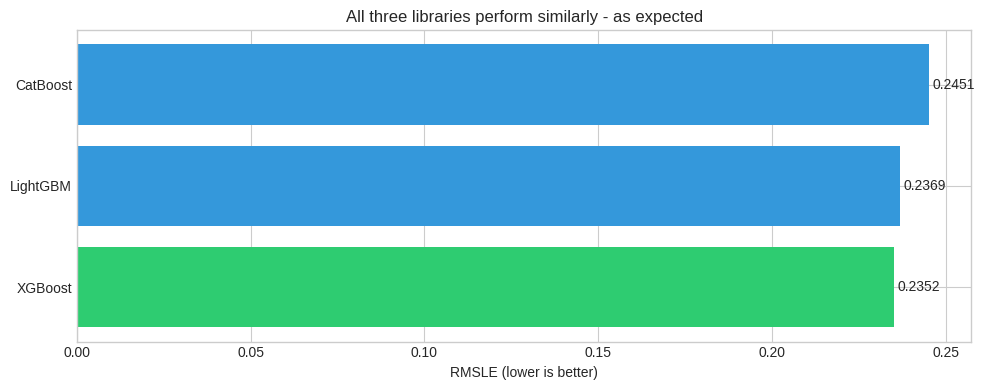


Difference between best and worst: 0.0099
This is a tiny difference. Your choice of library rarely matters.
Spend your time on feature engineering instead.


In [57]:
# Side-by-side comparison of all three libraries
# Remember: these are all gradient boosting - the algorithm is the same,
# just implemented differently by each library

comparison_results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'RMSLE': [xgb_rmse, lgb_rmse, catboost_rmse]
}).sort_values('RMSLE')

print("Gradient Boosting Library Comparison:")
print("=" * 40)
for _, row in comparison_results.iterrows():
    marker = " ← best" if row['RMSLE'] == comparison_results['RMSLE'].min() else ""
    print(f"{row['Model']:<12} RMSLE: {row['RMSLE']:.4f}{marker}")

# Visualize the comparison
fig, ax = plt.subplots(figsize=(10, 4))

# Color the best one green, rest blue
bar_colors = [
    '#2ecc71' if score == comparison_results['RMSLE'].min() else '#3498db' 
    for score in comparison_results['RMSLE']
]

bars = ax.barh(comparison_results['Model'], comparison_results['RMSLE'], color=bar_colors)
ax.set_xlabel('RMSLE (lower is better)')
ax.set_title('All three libraries perform similarly - as expected')

# Add the actual values as labels
for bar, score in zip(bars, comparison_results['RMSLE']):
    ax.text(score + 0.001, bar.get_y() + bar.get_height()/2, 
            f'{score:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# Calculate how different they really are
score_spread = comparison_results['RMSLE'].max() - comparison_results['RMSLE'].min()
print(f"\nDifference between best and worst: {score_spread:.4f}")
print("This is a tiny difference. Your choice of library rarely matters.")
print("Spend your time on feature engineering instead.")

**My Personal Workflow:**

1. **Quick exploration:** LightGBM with defaults + early stopping. Fast iteration.
2. **Messy categorical data:** CatBoost. Let it handle the encoding.
3. **Production deployment:** Often XGBoost, simply because it has the most documentation and community support. But any of them work.
4. **Kaggle competitions:** Try all three, ensemble them if the rules allow.

**The key takeaways for gradient boosting:**

- Always use early stopping. Always.
- Start with learning_rate around 0.05-0.1
- For temporal data, make sure to split the data based on time periods, where validation would be the rows of later data.
- Don't over-tune. The defaults are pretty good.
- Library choice matters less than feature engineering

Now let's look at how to systematically tune these models using Optuna.

## Hyperparameter Tuning with Optuna

So far we've used mostly default parameters. But gradient boosting has many knobs to turn: learning rate, tree depth, sampling rates, L1/L2 penalties, and more. Finding good values manually is tedious and time-consuming.

**Optuna** is a hyperparameter optimization library that does this automatically. Instead of random search or grid search (trying every combination), Optuna uses **Bayesian optimization** - it learns from previous trials which parameter regions are promising, and focuses its search there.

Think of it like this:
- Grid search: "Let me try every combination" (slow, wasteful)
- Random search: "Let me try random combinations" (better, but still blind)
- Optuna: "That last trial with low learning rate worked well, let me explore that region more" (smart, efficient)

**How Optuna Works**

You define an "objective function" that:
1. Receives a `trial` object from Optuna
2. Asks Optuna to suggest parameter values (`trial.suggest_float()`, `trial.suggest_int()`)
3. Trains a model with those parameters
4. Returns a score (lower is better for RMSE)

Optuna runs this function many times, each time suggesting different parameters based on what it learned from previous runs.

In [58]:
import optuna

def lightgbm_objective(trial):
    """
    Optuna calls this function repeatedly with different parameter suggestions.
    We train a model, evaluate it, and return the score.
    Optuna uses the score to decide what parameters to try next.
    """
    
    # trial.suggest_* asks Optuna: "give me a value in this range"
    # Optuna picks values it thinks will work well based on previous trials
    
    params = {
        # Learning rate: log scale because 0.01 vs 0.02 matters more than 0.2 vs 0.21
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        
        # Tree complexity
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        
        # Sampling (like Random Forest's randomness)
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),         # Row sampling
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),  # Column sampling
        
        # Regularization (L1 and L2 penalties to prevent overfitting)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),   # L1
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True), # L2
        
        # Fixed params (not tuning these)
        'n_estimators': 1000,  # High ceiling, early stopping will find optimal
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    # Train with early stopping on our validation set
    model = lgb.LGBMRegressor(**params)
    model.fit(
        features_train, target_train,
        eval_set=[(features_validation, target_validation)],
        callbacks=[lgb.early_stopping(30, verbose=False)]
    )
    
    # Evaluate and return the score
    predictions = model.predict(features_validation)
    rmse = calculate_rmse(predictions, target_validation)
    
    return rmse  # Optuna will try to minimize this

Now we run the optimization. Each "trial" trains a model with different parameters. More trials = better chance of finding good parameters, but takes longer.

For quick demos: 20-30 trials. For serious tuning: 100+ trials.

In [59]:
# Suppress Optuna's verbose output (it logs a lot by default)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Create a "study" - Optuna's term for an optimization run
# direction='minimize' because lower RMSE is better
study = optuna.create_study(direction='minimize')

# Run the optimization
# n_trials=30 means "try 30 different parameter combinations"
print("Running 30 trials of hyperparameter optimization...")
print("(Each trial trains a LightGBM model with different parameters)\n")

study.optimize(lightgbm_objective, n_trials=30, show_progress_bar=True)

print(f"\nOptimization complete!")
print(f"Best RMSLE found: {study.best_value:.4f}")

Running 30 trials of hyperparameter optimization...
(Each trial trains a LightGBM model with different parameters)



  0%|          | 0/30 [00:00<?, ?it/s]


Optimization complete!
Best RMSLE found: 0.2318


In [60]:
# Let's see what parameters Optuna found to be best
print("Best parameters found:")
print("=" * 40)

for param_name, param_value in study.best_params.items():
    if isinstance(param_value, float):
        print(f"  {param_name}: {param_value:.6f}")
    else:
        print(f"  {param_name}: {param_value}")

print("\nThese are the parameter values that gave the lowest RMSLE.")

Best parameters found:
  learning_rate: 0.068821
  num_leaves: 113
  max_depth: 9
  subsample: 0.784750
  colsample_bytree: 0.530792
  reg_alpha: 0.000009
  reg_lambda: 0.000003

These are the parameter values that gave the lowest RMSLE.


**Training the Final Model**

Now we train a final model using the best parameters Optuna found. We'll use early stopping to find the optimal number of trees.

In [61]:
# Build final model with best parameters
best_params = study.best_params.copy()

# Add the fixed parameters that weren't tuned
best_params['n_estimators'] = 2000  # High ceiling
best_params['random_state'] = 42
best_params['n_jobs'] = -1
best_params['verbose'] = -1

tuned_lightgbm = lgb.LGBMRegressor(**best_params)

tuned_lightgbm.fit(
    features_train, target_train,
    eval_set=[(features_validation, target_validation)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

tuned_predictions = tuned_lightgbm.predict(features_validation)
tuned_rmse = calculate_rmse(tuned_predictions, target_validation)

# Compare to our default LightGBM from earlier
print("Tuning Results:")
print("=" * 45)
print(f"Default LightGBM RMSLE:  {lgb_rmse:.4f}")
print(f"Tuned LightGBM RMSLE:    {tuned_rmse:.4f}")

improvement = (lgb_rmse - tuned_rmse) / lgb_rmse * 100
if improvement > 0:
    print(f"\nImprovement: {improvement:.2f}%")
else:
    print(f"\nNo improvement (defaults were already good for this data)")

print(f"\nTrees used: {tuned_lightgbm.best_iteration_}")

Tuning Results:
Default LightGBM RMSLE:  0.2369
Tuned LightGBM RMSLE:    0.2305

Improvement: 2.72%

Trees used: 1111


**Practical Notes on Hyperparameter Tuning**

A few things I've learned about tuning:

1. **Diminishing returns.** Going from default to tuned might give you 1-5% improvement. Going from 30 trials to 300 trials might give you another 0.5%. Know when to stop.

2. **Feature engineering usually matters more.** If your RMSLE is 0.25, tuning might get you to 0.24. A good feature could get you to 0.20.

3. **Don't tune on test data.** We used validation data for tuning. The test set should remain untouched until final evaluation. Otherwise you're indirectly overfitting to it.

4. **The parameters that matter most:** learning_rate, max_depth/num_leaves, and regularization (reg_alpha, reg_lambda). The sampling parameters (subsample, colsample_bytree) help but are less critical.

5. **Optuna is smart but not magic.** If your model fundamentally can't capture the pattern (wrong features, wrong algorithm), no amount of tuning will fix it.

## Model Interpretation with SHAP

Earlier we looked at **feature importance** from Random Forest. That tells us which features matter *in general* across all predictions. It's a global view: "YearMade is the most important feature overall."

But feature importance can't answer: **Why did the model predict THIS specific price for THIS specific bulldozer?**

That's where SHAP comes in.

**Feature Importance vs SHAP:**

| Feature Importance | SHAP |
|-------------------|------|
| Global only | Both global AND individual predictions |
| "YearMade matters a lot" | "YearMade=2008 pushed THIS prediction down by $3k" |
| Single number per feature | Direction + magnitude for each prediction |
| Fast to compute | Slower (but more informative) |

SHAP (SHapley Additive exPlanations) answers: **"How much did each feature push this specific prediction up or down from the average?"**

Example: If average price is $40k and model predicts $55k for a specific bulldozer, SHAP might show:
- YearMade=2010 → +$8k (newer than average)
- Low usage hours → +$5k (less wear)
- Missing AC enclosure → -$2k (less desirable)
- ProductSize=Large → +$4k (bigger machines cost more)

Sum: $40k + $8k + $5k - $2k + $4k = $55k

This is incredibly useful for explaining predictions to stakeholders, debugging unexpected predictions, and understanding model behavior.

E.g, consider a few of these scenarios:
- A bank customer wants to know why they were denied taking a loan (classification)
- An employee wants to know why their salary was a specific number (regression)

In [62]:
import shap

# Use subset for speed (SHAP is computationally expensive)
sample_size = 1000
np.random.seed(42)
sample_indices = np.random.choice(len(features_validation), sample_size, replace=False)
features_sample = features_validation.iloc[sample_indices]

# TreeExplainer is optimized for tree-based models
explainer = shap.TreeExplainer(tuned_lightgbm)
shap_values = explainer.shap_values(features_sample)

print(f"SHAP values computed for {sample_size} samples")
print(f"Shape: {shap_values.shape} (samples × features)")

SHAP values computed for 1000 samples
Shape: (1000, 60) (samples × features)


### Summary Plot (Beeswarm)

Shows global feature importance with value distributions:
- Each row = one feature
- Each dot = one sample
- Position (left/right) = SHAP value (pushes prediction down/up)
- Color = feature value (blue=low, red=high)

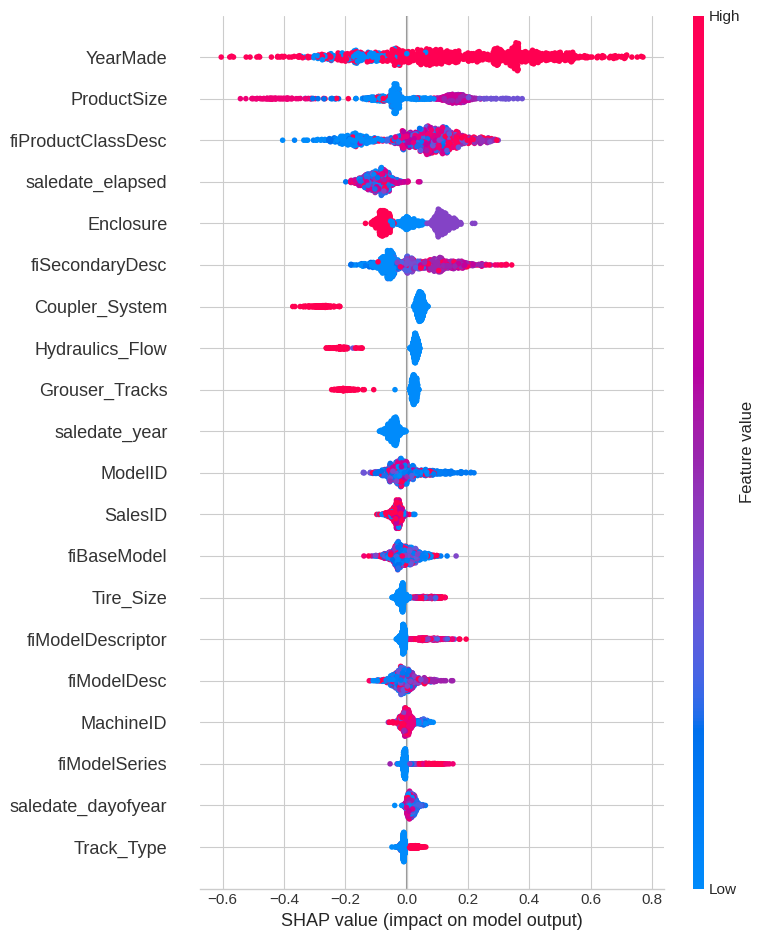

In [63]:
shap.summary_plot(shap_values, features_sample, plot_type='dot', show=True)

**Reading the summary plot:**

Look for color patterns:
- **Red dots on right, blue on left**: Higher feature values → higher predictions (positive relationship)
- **Blue dots on right, red on left**: Higher feature values → lower predictions (negative relationship)
- **Mixed colors**: Complex or non-linear relationship

For example, `YearMade` typically shows red (newer) on right (higher price) and blue (older) on left (lower price).

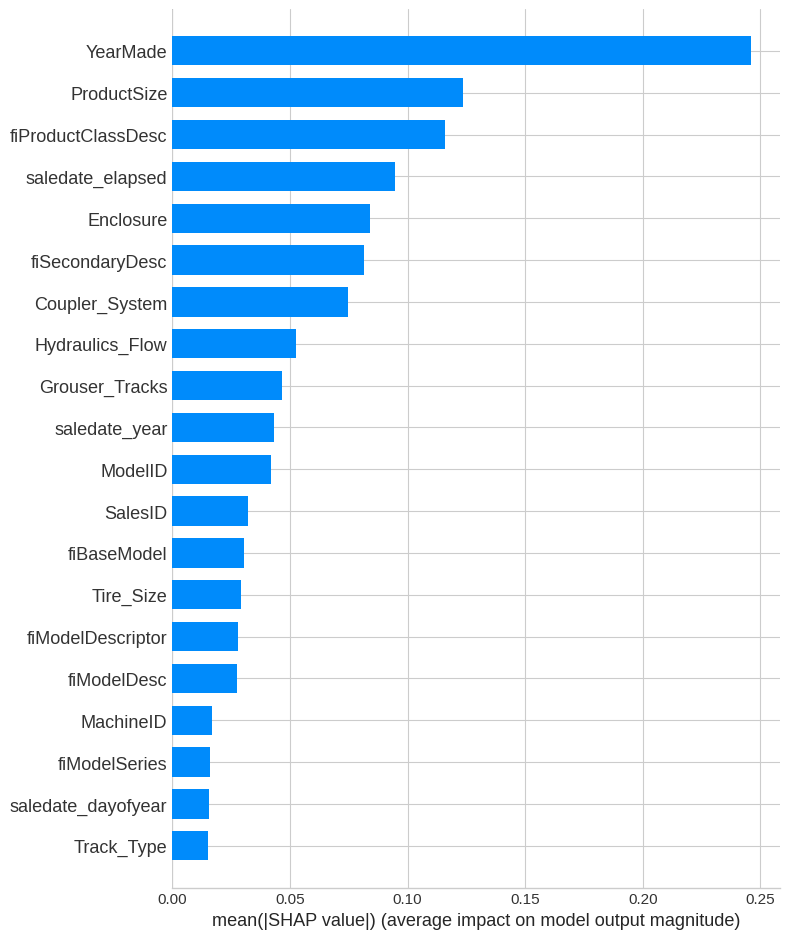

In [64]:
# Bar chart shows mean |SHAP| - overall importance without direction
shap.summary_plot(shap_values, features_sample, plot_type='bar', show=True)

### Explaining a Single Prediction

The **waterfall plot** explains one specific prediction - useful for answering "why did the model predict this price for this equipment?"

Explaining prediction for sample 0:
  Predicted (log): 11.036 → $62,087
  Actual (log):    11.191 → $72,500



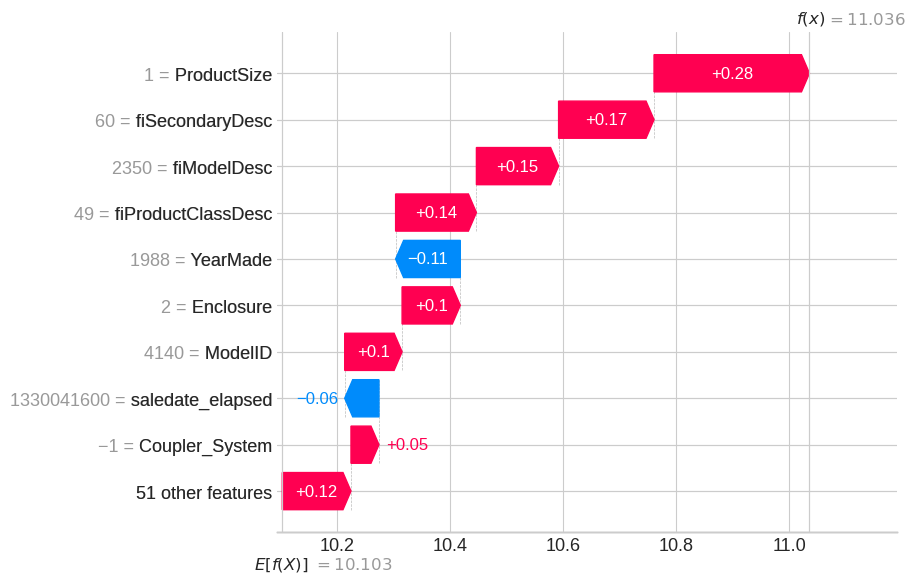

In [65]:
# Explain first sample in our subset
prediction_index = 0

# Get the actual prediction and true value for context
actual_pred = tuned_lightgbm.predict(features_sample.iloc[[prediction_index]])[0]
actual_true = target_validation.iloc[sample_indices[prediction_index]]

print(f"Explaining prediction for sample {prediction_index}:")
print(f"  Predicted (log): {actual_pred:.3f} → ${np.exp(actual_pred):,.0f}")
print(f"  Actual (log):    {actual_true:.3f} → ${np.exp(actual_true):,.0f}")
print()

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[prediction_index],
        base_values=explainer.expected_value,
        data=features_sample.iloc[prediction_index],
        feature_names=features_sample.columns.tolist()
    )
)

**Reading the waterfall:**
- Starts at E[f(x)] = average prediction (base value)
- Each bar shows one feature's contribution
- Red bars push prediction up, blue bars push down
- Final prediction is sum of base + all contributions

### Dependence Plot

Shows how one feature's value affects its SHAP contribution. Reveals non-linear relationships that aren't obvious from the summary plot.

Dependence plot for: YearMade


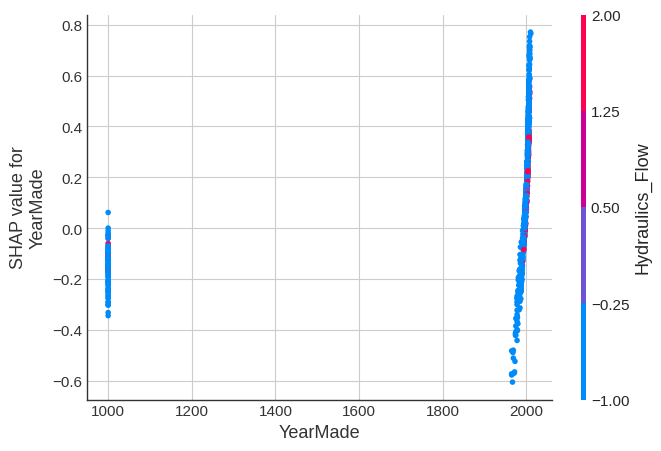

In [66]:
top_feature = feature_importance.iloc[0]['feature']
print(f"Dependence plot for: {top_feature}")

shap.dependence_plot(top_feature, shap_values, features_sample, show=True)

**Reading the dependence plot:**
- X-axis: feature value
- Y-axis: SHAP value (contribution to prediction)
- Color: interaction feature (auto-selected to show strongest interaction)

Look for:
- **Upward trend**: Higher values → higher predictions
- **Plateau**: Feature stops mattering beyond some threshold
- **Color separation**: Another feature modifies this relationship

## Neural Networks on Tabular Data

How do neural networks compare to trees on tabular data? Research consistently shows: **trees usually win or tie**.

Key differences:
| Aspect | Trees | Neural Networks |
|--------|-------|----------------|
| Preprocessing | Minimal | Requires normalization |
| Categoricals | Native handling | Need embeddings |
| Tuning | Robust to defaults | Sensitive to architecture |
| Speed | Fast | Slower training |
| Extrapolation | Cannot extrapolate | Can (sometimes) |

In [67]:
features_train

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,fiSecondaryDesc,fiModelSeries,fiModelDescriptor,ProductSize,fiProductClassDesc,state,ProductGroup,ProductGroupDesc,Drive_System,Enclosure,Forks,Pad_Type,Ride_Control,Stick,Transmission,...,Tire_Size,Coupler,Coupler_System,Grouser_Tracks,Hydraulics_Flow,Track_Type,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saledate_year,saledate_month,saledate_day,saledate_dayofweek,saledate_dayofyear,saledate_quarter,saledate_is_month_start,saledate_is_month_end,saledate_elapsed
0,1139246,999089,3157,121,3.0,2004,68.0,1,962,297,42,-1,-1,-1,58,0,5,5,-1,2,0,-1,1,-1,-1,...,16,2,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,3,1,2006,11,16,3,320,4,0,0,1163635200
1,1139248,117657,77,121,3.0,1996,4640.0,1,1744,528,56,97,-1,3,61,32,5,5,-1,2,0,-1,1,-1,-1,...,11,2,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,3,1,2004,3,26,4,86,1,0,0,1080259200
2,1139249,434808,7009,121,3.0,2001,2838.0,0,335,110,-1,-1,-1,-1,38,31,2,2,-1,5,0,-1,-1,-1,-1,...,-1,2,0,0,2,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,2004,2,26,3,57,1,0,0,1077753600
3,1139251,1026470,332,121,3.0,2001,3486.0,0,3715,1380,-1,44,-1,5,7,43,3,3,-1,2,-1,-1,-1,-1,-1,...,-1,2,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,2011,5,19,3,139,2,0,0,1305763200
4,1139253,1057373,17311,121,3.0,2007,722.0,2,4260,1537,-1,-1,-1,-1,39,31,2,2,-1,0,0,-1,-1,-1,-1,...,-1,2,0,0,2,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,2009,7,23,3,204,3,0,0,1248307200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401120,6333336,1840702,21439,149,1.0,2005,0.0,-1,665,208,107,62,-1,4,16,19,3,3,-1,0,-1,-1,-1,-1,-1,...,-1,2,-1,-1,-1,1,18,28,2,1,0,-1,-1,-1,-1,-1,2011,11,2,2,306,4,0,0,1320192000
401121,6333337,1830472,21439,149,1.0,2005,0.0,-1,665,208,107,62,-1,4,16,19,3,3,-1,0,-1,-1,-1,-1,-1,...,-1,2,-1,-1,-1,1,18,28,2,1,0,-1,-1,-1,-1,-1,2011,11,2,2,306,4,0,0,1320192000
401122,6333338,1887659,21439,149,1.0,2005,0.0,-1,665,208,107,62,-1,4,16,19,3,3,-1,0,-1,-1,-1,-1,-1,...,-1,2,-1,-1,-1,1,18,28,2,1,0,-1,-1,-1,-1,-1,2011,11,2,2,306,4,0,0,1320192000
401123,6333341,1903570,21435,149,2.0,2005,0.0,-1,489,159,107,-1,-1,4,12,8,3,3,-1,0,-1,-1,-1,-1,-1,...,-1,2,-1,-1,-1,1,18,28,2,1,0,-1,-1,-1,-1,-1,2011,10,25,1,298,4,0,0,1319500800


In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor

# Neural networks need normalized features (mean=0, std=1)
scaler = StandardScaler()

# Fit on training only (avoid data leakage)
features_train_scaled = scaler.fit_transform(features_train)
features_validation_scaled = scaler.transform(features_validation)

print(f"Before scaling - mean: {features_train.values.mean():.1f}, std: {features_train.values.std():.1f}")
print(f"After scaling  - mean: {features_train_scaled.mean():.1f}, std: {features_train_scaled.std():.1f}")

Before scaling - mean: 18243086.6, std: 141673166.3
After scaling  - mean: -0.0, std: 1.0


In [ ]:
# L07: Trees - Random Forests & Gradient Boosting

In Lesson 6, we built a full pipeline for tabular data using an MLP with embeddings. We dealt with missing values, encoded categories, scaled features, handled class imbalance, and evaluated with proper metrics. The MLP worked, but here's the honest truth: for tabular data, tree-based models often win. They're faster to train, easier to interpret, need less preprocessing, and frequently deliver equal or better accuracy. This lesson is about giving you the right tool for the job.

We'll build decision trees, random forests, and gradient boosting models (XGBoost, LightGBM, CatBoost) on a real dataset and compare them head-to-head with the MLP approach from L6. The goal isn't to pick a favorite - it's to understand when each approach makes sense. By the end, you'll have a practical framework: try trees first on tabular, use neural nets for images and text, and always compare.

## Key Concepts

**Decision Trees** - the building block of everything in this lesson. A decision tree makes predictions by asking a series of yes/no questions. "Is the year made before 2000?" If yes, go left. If no, go right. Keep splitting until you reach a leaf, which holds the prediction (the average value of all training samples that ended up there).

The tree algorithm picks splits automatically by testing every feature at every possible threshold, choosing the one that creates the most homogeneous groups. For regression, "homogeneous" means low variance (prices within each group are similar). For classification, it means low Gini impurity (most samples in each group belong to the same class).

Pros: interpretable (you can read the rules), no preprocessing needed (trees don't care about scale), handles missing values. Cons: a single deep tree overfits badly - it memorizes the training data by creating leaves with just a few samples each.

**Random Forests** - the fix for overfitting. Train many decision trees (typically 100+), each on a random subset of the data (bootstrap sampling) using a random subset of features at each split. Then average their predictions.

Why does averaging work? Each tree sees different data and different features, so they make different mistakes. When you average many uncorrelated errors, they tend to cancel out. The result is a model that's much more stable and accurate than any single tree. It's the same principle as asking 100 people to estimate the weight of a cow - the average is usually better than any individual guess.

**Bagging (Bootstrap Aggregating)** - the technique behind random forests. Draw N samples with replacement from N training samples. Some samples appear multiple times, roughly 37% don't appear at all. Train a tree on each bootstrap sample. The samples that didn't appear become the "out-of-bag" (OOB) set - a free validation set for each tree.

**Out-of-Bag Error** - for each training sample, some trees never saw it during training. We can collect predictions from only those trees and get a validation-like score without setting aside any data. Useful when data is limited. For time-series data, use a proper temporal split instead.

**Feature Importance** - random forests track how much each feature contributes to reducing prediction error across all trees. This tells you which features matter most. In the notebook, we'll see that a handful of features dominate while dozens contribute almost nothing - a common pattern that lets us simplify the model.

**Prediction Confidence** - since a random forest is 100 trees each giving their own prediction, the spread (standard deviation) of those predictions tells you how confident the model is. Low spread means the trees agree - high confidence. High spread means they disagree - the model is uncertain. This is practically useful: in production, you can route uncertain predictions to human review.

**Gradient Boosting** - a different ensemble strategy. Instead of training trees independently and averaging (random forest), train trees sequentially. Each new tree focuses specifically on the errors of all previous trees combined. Tree 1 makes predictions. Tree 2 predicts the residuals (mistakes) of tree 1. Tree 3 predicts the residuals of trees 1+2 combined. Stack enough trees and the ensemble gets very accurate.

The tradeoff: gradient boosting is more powerful but also more fragile. It can overfit if you add too many trees or use too high a learning rate. That's why early stopping is essential - monitor validation performance and stop adding trees when it stops improving.

**XGBoost, LightGBM, CatBoost** - three popular implementations of gradient boosting. XGBoost is the battle-tested standard. LightGBM is faster (great for quick experiments). CatBoost handles categorical features natively. In practice, the differences in accuracy are usually small - good feature engineering matters more than library choice.

**SHAP (SHapley Additive exPlanations)** - goes beyond feature importance. Instead of "which features matter globally?", SHAP answers "why did the model make this specific prediction?" For each prediction, SHAP shows how each feature pushed the prediction up or down from the average. A waterfall plot shows one prediction decomposed. A beeswarm plot shows patterns across all predictions.

**When to Use What** - a practical decision framework:

- Tabular data: try trees first. They're fast, need minimal preprocessing, and often best
- Images/text/audio: neural nets. Trees can't handle spatial or sequential structure
- Small data: trees. They need fewer samples to learn useful patterns
- Interpretability matters: trees or SHAP on top of gradient boosting
- Always worth trying both and comparing honestly

**Tree Extrapolation Limitation** - trees can only predict values within the range they saw during training. If training prices go up to $100k, the tree can never predict $150k. Neural nets don't have this constraint. Keep this in mind with time-series or trend data.

## Terminology

| Term | What it means | Where we see it |
| --- | --- | --- |
| **Decision tree** | Model that predicts by following a chain of yes/no splits | Visualized tree with nodes and leaves |
| **Gini impurity** | How mixed a group is after splitting (classification) | Split quality scoring |
| **Random forest** | Ensemble of trees trained on random data/feature subsets | 100 trees averaged together |
| **Bagging** | Bootstrap aggregating - train on random samples with replacement | Each tree sees ~63% of data |
| **Out-of-bag (OOB)** | Samples a tree never trained on, used as free validation | ~37% of data per tree |
| **Ensemble** | Combining multiple models to get better predictions | Random forest, gradient boosting |
| **Feature importance** | How much each feature reduces prediction error across all trees | Bar chart of top features |
| **Gradient boosting** | Trees trained sequentially, each correcting previous errors | XGBoost, LightGBM, CatBoost |
| **Early stopping** | Stop training when validation performance stops improving | Prevents gradient boosting from overfitting |
| **Learning rate (boosting)** | How much each new tree's correction counts | Lower = more trees needed, but more stable |
| **SHAP values** | Per-feature contribution to a specific prediction | Waterfall and beeswarm plots |
| **Extrapolation** | Predicting beyond the range seen in training | Trees can't do this, neural nets can |
| **Log transform** | Taking log of skewed target to normalize the distribution | log(price) makes RMSE work better |

## Connection to L6 and L8

**From L6:** The pipeline skills transfer directly - data exploration, preprocessing, train/val splitting, evaluation metrics. The difference is that trees need much less preprocessing (no normalization, no embeddings, handles missing values). The confusion matrix, precision, recall, and F1 concepts from L6 apply exactly the same way to tree classifiers. We also rebuild the MLP from L6 for a fair head-to-head comparison.

**To L8:** L8 is a project assistance lesson with no new content. You consolidate everything from L1-L7 - both the neural net pipeline (L5-L6) and the tree-based approach (L7). The goal is solid tabular ML fluency before switching to a fundamentally different data domain: images. The pipeline patterns, evaluation discipline, and "right tool for the job" thinking from these lessons carry forward into everything that follows.

## Resources

This lesson by Jeremy Howard in the fastai course is a great place to start with tree models:

- The first lecture which you can start watching from 1:26:40 https://www.youtube.com/watch?v=_rXzeWq4C6w&list=PLfYUBJiXbdtSvpQjSnJJ_PmDQB_VyT5iU&index=5
- And the continuation of that lecture all the way up until 52 minutes https://www.youtube.com/watch?v=AdhG64NF76E&list=PLfYUBJiXbdtSvpQjSnJJ_PmDQB_VyT5iU&index=8

They are based on a lecture notebook which is included in your repository in the fastai_course_notebooks just for convenience (*07-how-random-forests-really-work.ipynb*) and *09_tabular.ipynb*, which is from his book “fastbook” which is more theory heavy but is worth reading. Once you’ve gone through these, the UA course lecture notebook will be better since its quite similar, but is more realistic, and streamlined - it mixes theory, but it also goes more into depth on gradient boosted trees, as they are generally more favored in real projects.

### These are all great to go more into depth and see more variety. Statquest has a lot of videos on tree based algorithms, I’ve cherry picked the best ones, but you might feel like watching through all his videos for each type.

- StatQuest - Decision and Classification Trees, Clearly Explained (18 min, excellent visual walkthrough of how trees split data using Gini impurity, a must-watch before the lesson): https://www.youtube.com/watch?v=_L39rN6gz7Y → He has more videos on decision trees, you don’t have to watch them, but at some point you may want to deepdive.
- StatQuest - Random Forests Part 1: Building, Using and Evaluating (10 min, builds from decision trees to the full random forest concept): https://www.youtube.com/watch?v=J4Wdy0Wc_xQ → Decision trees are the foundation of tree based models, but random forests is a clear usable algorithm that actually uses decision trees (think of it like creating massive amounts of decision trees, we call those random forests)
- StatQuest - Regression Trees, Clearly Explained (9 min, how trees handle continuous targets instead of categories): https://www.youtube.com/watch?v=g9c66TUylZ4
- Gradient Boosted Trees (StatQuest, 15 min, explains the sequential learning process clearly - watch after understanding decision trees and random forests): https://www.youtube.com/watch?v=3CC4N4z3GJc
- Gradient Boosting for classification (StatQuest, 11 min, extends the regression explanation to classification tasks): https://www.youtube.com/watch?v=jxuNLH5dXCs
- Gradient Boosted Trees  https://www.youtube.com/watch?v=PxgVFp5a0E4

### Model interpretation - These are great and easy to understand

Tree-based algorithms are great because we can peak inside of them to see what they actually do, unlike neural networks. 

- SHAP - Model Interpretation (visual explanation of SHAP values and how to read the plots we use in the notebook): https://www.youtube.com/watch?v=MQ6fFDwjuco
- Model Interpretable vs Explainable (short, clarifies the difference between models you can read directly vs models you need tools to explain): https://www.youtube.com/watch?v=VY7SCl_DFho

### Documentation

- scikit-learn Decision Trees (official docs, covers both classification and regression trees with API reference): https://scikit-learn.org/stable/modules/tree.html
- scikit-learn Random Forests (official docs, ensemble methods including random forests and gradient boosting): https://scikit-learn.org/stable/modules/ensemble.html
- XGBoost documentation (getting started guide and parameter tuning): https://xgboost.readthedocs.io/en/latest/
- LightGBM documentation (quick start and key differences from XGBoost): https://lightgbm.readthedocs.io/en/latest/
- SHAP documentation (Python library for model interpretation, includes tutorial notebooks): https://shap.readthedocs.io/en/latest/

MLP RMSLE:            0.2850
Tuned LightGBM RMSLE: 0.2305

Training stopped at epoch 165


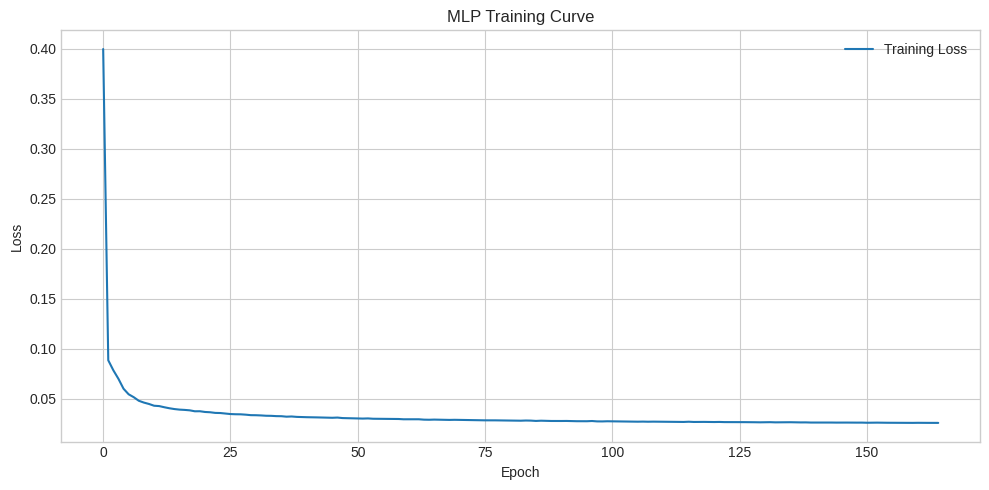

In [70]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(mlp_model.loss_curve_, label='Training Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('MLP Training Curve')
ax.legend()
plt.tight_layout()
plt.show()

**Why trees often beat NNs on tabular data:**

1. Trees handle heterogeneous features naturally (mix of categorical, ordinal, continuous)
2. Integer-encoded categoricals are suboptimal for NNs (embeddings would help)
3. Tree ensembles are more robust to hyperparameter choices
4. Tabular data often has complex feature interactions that trees capture well

**When NNs might win:**
- Very large datasets (millions of rows)
- Multi-modal data (tabular + images/text)
- When proper embeddings are used for categoricals
- When extrapolation beyond training range is needed

### Tree Extrapolation Limitation

Trees **cannot extrapolate** beyond training data range. A tree's prediction is always the average of training samples in a leaf - by construction, it can only output values seen during training.

**Implications:**
- If training prices range $10k-$100k, tree can never predict $150k
- Time trends don't extend (prices rising year-over-year won't continue)
- Novel combinations may get wrong predictions

Neural networks *can* extrapolate (with varying success), which is one reason to consider them for forecasting tasks.

## Ensembling: Combining Models

Since XGBoost, LightGBM, and CatBoost make slightly different errors, averaging their predictions often improves results - the same principle behind random forests.

In [71]:
# Simple average
ensemble_predictions = (xgb_predictions + lightgbm_predictions + catboost_predictions) / 3
ensemble_rmse = calculate_rmse(ensemble_predictions, target_validation)

# Weighted average (better models get higher weight)
errors = np.array([xgb_rmse, lgb_rmse, catboost_rmse])
weights = 1 / errors
weights = weights / weights.sum()

weighted_predictions = (
    weights[0] * xgb_predictions +
    weights[1] * lightgbm_predictions +
    weights[2] * catboost_predictions
)
weighted_rmse = calculate_rmse(weighted_predictions, target_validation)

print("Ensemble Results:")
print("=" * 45)
print(f"{'Model':<25} RMSLE")
print("-" * 45)
print(f"{'XGBoost':<25} {xgb_rmse:.4f}")
print(f"{'LightGBM':<25} {lgb_rmse:.4f}")
print(f"{'CatBoost':<25} {catboost_rmse:.4f}")
print(f"{'Simple Average':<25} {ensemble_rmse:.4f}")
print(f"{'Weighted Average':<25} {weighted_rmse:.4f}")
print("=" * 45)
print(f"\nWeights: XGB={weights[0]:.2f}, LGB={weights[1]:.2f}, CB={weights[2]:.2f}")

Ensemble Results:
Model                     RMSLE
---------------------------------------------
XGBoost                   0.2352
LightGBM                  0.2369
CatBoost                  0.2451
Simple Average            0.2353
Weighted Average          0.2352

Weights: XGB=0.34, LGB=0.34, CB=0.33


## Classification with Trees

Everything we've learned applies to classification with one change: instead of minimizing variance (regression), we minimize **Gini impurity** (classification).

Let's convert our regression problem to classification: predict whether equipment sells above or below median price.

In [72]:
# Binary classification: above/below median price
median_price = train_data['SalePrice'].median()
print(f"Median price (from training): ${median_price:,.0f}")

target_train_binary = (train_data['SalePrice'] > median_price).astype(int)
target_validation_binary = (validation_data['SalePrice'] > median_price).astype(int)

print(f"\nClass distribution (training):")
print(f"  Low price (0):  {(target_train_binary == 0).sum():,} ({(target_train_binary == 0).mean():.1%})")
print(f"  High price (1): {(target_train_binary == 1).sum():,} ({(target_train_binary == 1).mean():.1%})")

Median price (from training): $24,000

Class distribution (training):
  Low price (0):  204,599 (51.0%)
  High price (1): 196,526 (49.0%)


In [73]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf_classifier.fit(features_train, target_train_binary)

# LightGBM Classifier
lgb_classifier = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_classifier.fit(
    features_train, target_train_binary,
    eval_set=[(features_validation, target_validation_binary)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

print("Classifiers trained.")

Classifiers trained.


### Classification Metrics

| Metric | What it Measures | Use When |
|--------|------------------|----------|
| **Accuracy** | % correct | Balanced classes |
| **Precision** | Of predicted positive, % truly positive | False positives costly |
| **Recall** | Of actual positive, % correctly found | False negatives costly |
| **F1** | Harmonic mean of precision/recall | Imbalanced classes |
| **AUC-ROC** | Area under ROC curve | Model comparison |

In [74]:
# Get predictions
rf_class_preds = rf_classifier.predict(features_validation)
rf_class_probs = rf_classifier.predict_proba(features_validation)[:, 1]

lgb_class_preds = lgb_classifier.predict(features_validation)
lgb_class_probs = lgb_classifier.predict_proba(features_validation)[:, 1]

# Compare metrics
print("Classification Results:")
print("=" * 50)
print(f"{'Metric':<15} {'Random Forest':<15} {'LightGBM':<15}")
print("-" * 50)
print(f"{'Accuracy':<15} {accuracy_score(target_validation_binary, rf_class_preds):<15.4f} {accuracy_score(target_validation_binary, lgb_class_preds):<15.4f}")
print(f"{'F1 Score':<15} {f1_score(target_validation_binary, rf_class_preds):<15.4f} {f1_score(target_validation_binary, lgb_class_preds):<15.4f}")
print(f"{'AUC-ROC':<15} {roc_auc_score(target_validation_binary, rf_class_probs):<15.4f} {roc_auc_score(target_validation_binary, lgb_class_probs):<15.4f}")
print("=" * 50)

Classification Results:
Metric          Random Forest   LightGBM       
--------------------------------------------------
Accuracy        0.9100          0.9128         
F1 Score        0.9167          0.9200         
AUC-ROC         0.9745          0.9759         


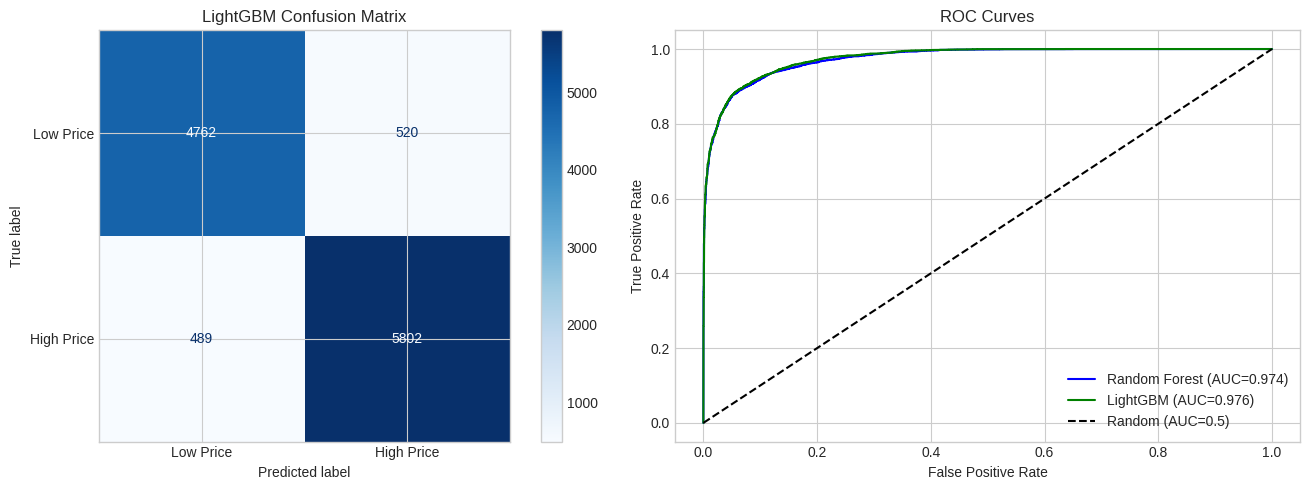

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix (LightGBM)
cm = confusion_matrix(target_validation_binary, lgb_class_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low Price', 'High Price'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('LightGBM Confusion Matrix')

# ROC Curve
for name, probs, color in [('Random Forest', rf_class_probs, 'blue'),
                            ('LightGBM', lgb_class_probs, 'green')]:
    fpr, tpr, _ = roc_curve(target_validation_binary, probs)
    auc = roc_auc_score(target_validation_binary, probs)
    axes[1].plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves')
axes[1].legend()

plt.tight_layout()
plt.show()

**Key differences from regression:**
- Target: categories instead of continuous values
- Metrics: accuracy, F1, AUC instead of RMSE
- Model: `Classifier` instead of `Regressor` (same API otherwise)
- Handle imbalance: `class_weight='balanced'`

## Final Summary

In [76]:
# Collect all regression results
final_results = pd.DataFrame({
    'Model': [
        'Decision Tree', 'Random Forest', 'RF (30 features)',
        'XGBoost', 'LightGBM', 'LightGBM (Tuned)', 'CatBoost',
        'MLP', 'Ensemble (avg)', 'Ensemble (weighted)'
    ],
    'RMSLE': [
        tree_rmse, rf_rmse, reduced_rmse,
        xgb_rmse, lgb_rmse, tuned_rmse, catboost_rmse,
        mlp_rmse, ensemble_rmse, weighted_rmse
    ]
}).sort_values('RMSLE')

print("FINAL MODEL COMPARISON")
print("=" * 45)
for _, row in final_results.iterrows():
    marker = " ← BEST" if row['RMSLE'] == final_results['RMSLE'].min() else ""
    print(f"{row['Model']:<25} RMSLE: {row['RMSLE']:.4f}{marker}")
print("=" * 45)

FINAL MODEL COMPARISON
LightGBM (Tuned)          RMSLE: 0.2305 ← BEST
Ensemble (weighted)       RMSLE: 0.2352
XGBoost                   RMSLE: 0.2352
Ensemble (avg)            RMSLE: 0.2353
LightGBM                  RMSLE: 0.2369
CatBoost                  RMSLE: 0.2451
RF (30 features)          RMSLE: 0.2485
Random Forest             RMSLE: 0.2624
MLP                       RMSLE: 0.2850
Decision Tree             RMSLE: 0.5252


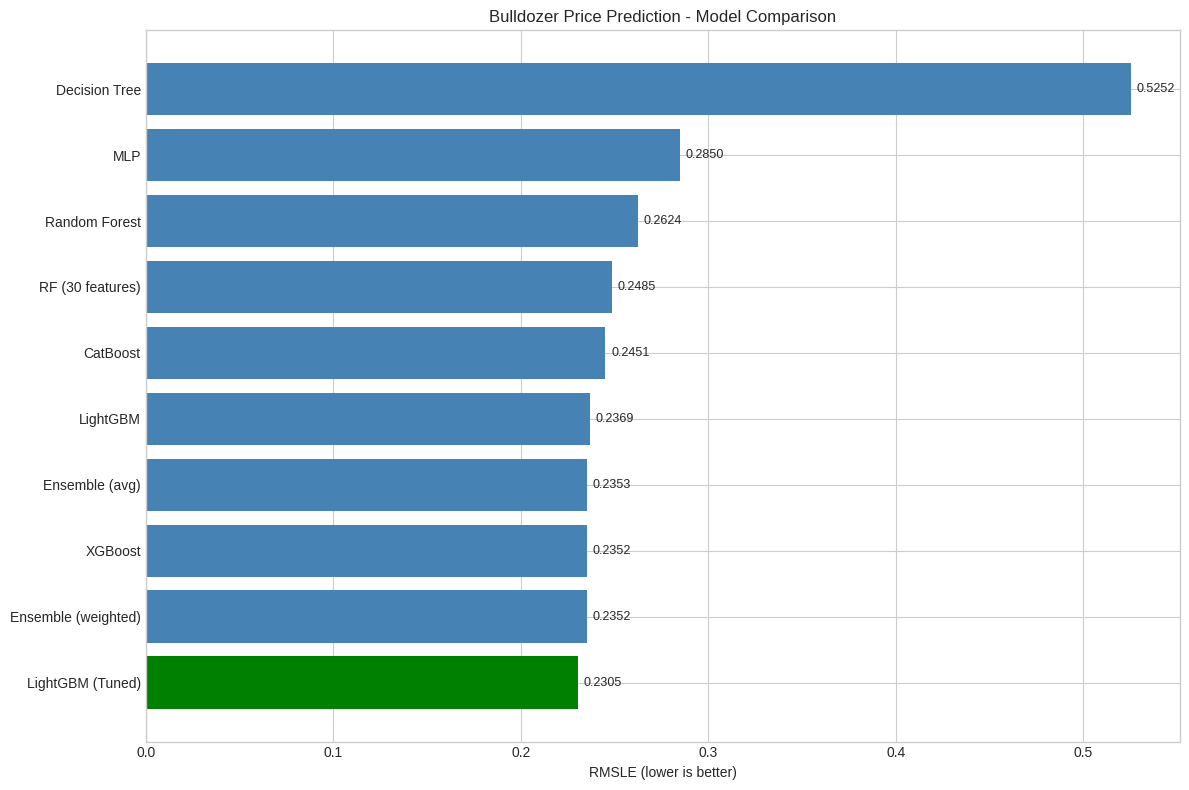

In [77]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['green' if x == final_results['RMSLE'].min() else 'steelblue' 
          for x in final_results['RMSLE']]
bars = ax.barh(final_results['Model'], final_results['RMSLE'], color=colors)
ax.set_xlabel('RMSLE (lower is better)')
ax.set_title('Bulldozer Price Prediction - Model Comparison')

for bar, val in zip(bars, final_results['RMSLE']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2, f'{val:.4f}', 
            va='center', fontsize=9)

plt.tight_layout()
plt.show()

### Key Learnings

**Algorithms:**
- **Decision trees**: Interpretable but limited capacity
- **Random forests**: Robust baseline, hard to overfit, built-in feature importance
- **Gradient boosting** (XGBoost/LightGBM/CatBoost): Often best accuracy, requires tuning
- **Neural networks**: Usually underperform trees on tabular data

**Practical techniques:**
- Time-based splits for temporal data
- Feature importance for selection and interpretation
- SHAP for explaining individual predictions
- Distribution shift detection with domain classifiers
- Ensembling for marginal gains

**Limitations:**
- Trees cannot extrapolate beyond training data range
- All models assume future resembles past

*Notebook created: 2025_01_27*

*Based on Fast.ai Practical Deep Learning Lesson 6, updated with modern libraries.*

<div style="text-align: center; color: #888; font-size: 0.85em; margin-top: 40px; padding-top: 10px; border-top: 1px solid #ddd;">
© 2025 Utvecklarakademin UA Aktiebolag. All rights reserved.<br>
This material is proprietary and may not be reproduced, distributed, or shared without written permission.
</div>